# All imports

In [1]:
import pandas as pd
import numpy as np
from scipy import stats 
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
from itertools import product
import pickle
import missingno
from tqdm.notebook import tqdm

In [2]:
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator
from dowhy import CausalModel
from dowhy.gcm import falsify

In [3]:
from statsmodels.formula.api import ols
import cbpys

In [4]:
from econml.dml import LinearDML, CausalForestDML
from econml.dr import ForestDRLearner, LinearDRLearner
from econml.metalearners import TLearner, XLearner, SLearner
from econml.inference import BootstrapInference
from econml.cate_interpreter import SingleTreeCateInterpreter
from econml.validate.drtester import DRTester
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [6]:
import geopandas as gpd
import rioxarray
import xarray as xr

import folium
from folium import raster_layers
from matplotlib.colors import Normalize
import branca.colormap as cm
from branca.element import MacroElement
from jinja2 import Template

In [7]:
import scipy.sparse
# This is to correct a bug in pygam
def to_array(self):
    return self.toarray()
scipy.sparse.spmatrix.A = property(to_array)
from pygam import LinearGAM, ExpectileGAM

In [8]:
data = pd.read_pickle('data/maize-soya-clean.pkl')
# data = data.loc[data.mainharvestcrop == 'maize']

# Causal model

## Variables and groups of variables in the model

In [9]:
# We will add variables to the data_subset as we will need them
data_base = pd.DataFrame(index=data.index)
data_base['crop_name'] = data.mainharvestcrop
data_base['crop_maize'] = data_base.crop_name == 'maize'
data_base['outcome_prodkgha'] = data.maizeprodkg_ha.fillna(data.soyaprodkg_ha)
data_base['outcome_prodstd'] = (data.maizeprodkg_ha - data.maizeprodkg_ha.mean())/data.maizeprodkg_ha.std()
data_base['outcome_prodstd'] = data_base.outcome_prodstd.fillna(
    (data.soyaprodkg_ha - data.soyaprodkg_ha.mean())/data.soyaprodkg_ha.std()
)
data_base['treat_previousadvice'] = data.previousadvice == 'yes'
data_base['fieldsize_value'] = data.harvestarea_ha
# data[['maizeprodkg_ha']].copy()
# data_subset = data_subset.rename(columns={'maizeprodkg_ha': 'prodkgha'})

In [10]:
# Soil variables
soil_df = data[[
    'carbon_organic_mean_0_20', 'cation_exchange_capacity_mean_0_20', 'clay_content_mean_0_20', 
    'sand_content_mean_0_20', 'bulk_density_mean_0_20',
]].copy()
soil_df = soil_df.rename(columns={
    'carbon_organic_mean_0_20': 'soilfert_oc', 'cation_exchange_capacity_mean_0_20': 'soilfert_cec',
    'clay_content_mean_0_20': 'soilpp_clay', 'sand_content_mean_0_20': 'soilpp_sand', 
    'bulk_density_mean_0_20': 'soilpp_density', 
})
soilfert_vars = ['soilfert_oc'] # Soil potential fertility
soilpp_vars = ['soilpp_clay', 'soilpp_sand', 'soilpp_density'] # Soil physical properties

In [11]:
# Fertilizer variables
fert_df = data[['KGNbasal_ha', 'KGPbasal_ha']].copy()
fert_df.columns = ['fertN_basal', 'fertP_basal']

for element in ('N', 'P'):
    for i in range(1, 4):
        tmp_df = data[[f'top{i}timing', f'KG{element}top{i}_ha']].copy()
        tmp_df[f'top{i}timing'] = tmp_df[f'top{i}timing'].replace({'tasseling': 'tasseling-silking', 'silking': 'tasseling-silking'})
        tmp_df = pd.pivot_table(
            tmp_df,
            values=f'KG{element}top{i}_ha', columns=f'top{i}timing',
            index='fieldID', fill_value=0, dropna=True
        )
        tmp_df = tmp_df.reindex(data.index)
        tmp_df.columns = tmp_df.columns.str.replace('-', '')
        tmp_df.columns = [f'fert{element}_{i}' for i in tmp_df.columns]
        for col in tmp_df.columns:
            if col in fert_df.columns:
                nan_rows = fert_df[col].isna() & tmp_df[col]
                fert_df[col] = fert_df[col].add(tmp_df[col], fill_value=0)
                fert_df.loc[nan_rows, col] = None
            else:
                fert_df[col] = tmp_df[col]
# Replace value with simple Bool
fert_df_values = fert_df.copy()
fert_df = fert_df.where(fert_df.isna(), fert_df > 0)

In [12]:
# Check that total fertilizer match
np.isclose(fert_df_values.sum(axis=1), data[['KGNtotal_ha', 'KGPtotal_ha']].sum(axis=1), rtol=.01).all()

np.True_

In [13]:
# Map each dev stage to season fraction
stages_map = {
    'planting': (0, 10),
    'emergence': (0, 10),
    '5-6-leaves': (10, 30),
    'knee-high': (20, 40),
    '8-10-leaves': (30, 50),
    'tasseling-silking': (40, 100),
}

In [14]:
# Rain through the different stages
rain_dev_stages_df = pd.DataFrame(index=data.index)
rain_dev_stages_df['wthstage_rain0to10'] = data['0to10perc_season_prec']
rain_dev_stages_df['wthstage_rain10to30'] = data[['10to20perc_season_prec', '20to30perc_season_prec']].sum(axis=1)
rain_dev_stages_df['wthstage_rain20to40'] = data[['20to30perc_season_prec', '30to40perc_season_prec']].sum(axis=1)
rain_dev_stages_df['wthstage_rain30to50'] = data[['30to40perc_season_prec', '40to50perc_season_prec']].sum(axis=1)
rain_dev_stages_df['wthstage_rainp40to100'] = data[[f'{i}to{i+10}perc_season_prec' for i in range(40, 100, 10)]].sum(axis=1)
rain_dev_stages_df['wthstage_rainp0to60'] = data[[f'{i}to{i+10}perc_season_prec' for i in range(0, 60, 10)]].sum(axis=1)

In [15]:
# Seasonal weather
wth_season_df = data[['0to100perc_season_prec', '0to100perc_season_srad']].copy()
wth_season_df.columns = ['wthseason_srad', 'wthseason_tmean']

In [16]:
# Phenology infor
phenology_df = pd.DataFrame(index=data.index)
phenology_df['phenology_losdays'] = data['estimated_los']
# Standardize LOS by crop
tmp_series = data.estimated_los.where(data.mainharvestcrop == 'maize', np.nan)
phenology_df['phenology_losstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.estimated_los.where(data.mainharvestcrop == 'soya', np.nan)
phenology_df['phenology_losstd'] = phenology_df.phenology_losstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)

In [17]:
# Varieties
variety_df = pd.DataFrame(index=data.index)
variety_df['variety_hybrid'] = ~data.maizevariety.isin(['LOCAL_VARIETY', 'CANNOT-REMEMBER-VARIETY', 'UNKNOWN_VARIETY'])
variety_df['variety_hybrid'] = ~variety_df.fillna(data.soyavariety.isin(['local', 'dontknow']))

#
variety_df['variety_recycled'] = data.maizerecycledseed == 'recycled'
variety_df['variety_recycled'] = variety_df.variety_recycled.fillna(
    data.maizerecycledseed.isin(['own', 'otherfarmer', 'relative_friend'])
)

In [18]:
# Crop history
# Define crop history with crop groups based on how they affect soil and managmeent
crop_groups = {
    'legume': ['beans', 'groundnuts', 'pigeonpea', 'soya'],
    'rootandtuber': ['cassava', 'roundpotatoes', 'sweetpotatoes'],
    'oilseed': ['sesame', 'sunflower']
}

def get_group_history(history:str):
    hist = {
        'history_maize': 'maize' in history,
        'history_nocrop': 'no_crop' in history
    }
    for group_name, crops in crop_groups.items():
        hist[f'history_{group_name}'] = any(map(lambda x: x in history, crops))
    return hist

history_df = pd.DataFrame.from_dict(data.crophistory.map(get_group_history).to_dict(), orient='index')

In [19]:
# External variables
external_df = data[['elevation', 'innacessibility_index']].copy()
external_df.columns = ['elevation_value', 'accessibility_rai']

In [20]:
# Residue will not be incorporated because it was measured for the end of the season, 
# therefore it could have not affected production. However it could serve as proxy,
# farmers doing it this time are more likely to do it every season
residue_df = pd.get_dummies(
    data.maizeresidues.where(
        data.maizeresidues.fillna(data.soyaresidues).isin(
            ['leave on field', 'burn', 'feed to animals', 'incorporate in the soil']
        ), 
        '0_other'
    ),
    prefix='residue_', drop_first=True, prefix_sep='' 
)
residue_df.columns = [col.replace(' ', '') for col in residue_df.columns]
residue_df['residue_onfield'] =  residue_df[['residue_incorporateinthesoil', 'residue_leaveonfield']].any(axis=1)

In [21]:
# Technology access
technology_df = pd.get_dummies(
    data.maizefieldprep.fillna(data.soyafieldprep), 
    prefix='tech', drop_first=False, prefix_sep=''
).iloc[:, [0,2,3]] 

technology_df.columns = ['technology_handhoe', 'technology_ploughcattle', 'technology_tractor']

In [22]:
# Herbicide
herbicide_df = pd.DataFrame(index=data.index)
herbicide_df['herbicide_post'] = data.maizeherbicides.str.contains('post-emergence').astype(bool)
herbicide_df['herbicide_pre'] = data.maizeherbicides.str.contains('pre-emergence').astype(bool)
herbicide_df['herbicide_any'] = herbicide_df.any(axis=1)

In [23]:
# Manure
manure_df = pd.get_dummies(data.manurefreq, drop_first=False).iloc[:, [0, 2, 3]]
manure_df.columns = ['manure_everyseason', 'manure_oneinmany', 'manure_oneintwo']
manure_df['manure_any'] = manure_df.any(axis=1)
# Leave this to be the only manure variable
manure_df = manure_df[['manure_any']]

In [24]:
# Planting practices
planting_df = pd.DataFrame(index=data.index)
planting_df = planting_df.join(pd.get_dummies(
    data.maizeplantingmethod.fillna(data.soyaplantingmethod), 
    drop_first=True, prefix='planting'
))
planting_df.columns = planting_df.columns.str.replace('-', '')

In [25]:
# Join all data
data_subset = pd.concat([
    data_base, fert_df, wth_season_df, rain_dev_stages_df, soil_df, phenology_df,
    variety_df, history_df, external_df, technology_df, manure_df, planting_df
], axis=1)

In [26]:
# Filter out rows with no production data
data_subset = data_subset[data_subset.outcome_prodkgha.notna()]

## Edges definition, create DAG

There will be some dummy nodes that will help to better define the causal paths. For example nodes that represent Nutrient uptake, Canopy expansion, Attainable yield, etc.

The edges were defined after an interative process with input from the stakeholder(s). The advice is mostly about nutrient management. They don't provide any advice on variety, but they have noticed that hybrid varieties are more prevalent among those that have received the advice. 

The only well known cause for the treatment assignment is the crop history. The extension agent is likely to be biased by their own personal context (e.g. give advice to farmers they know better), and the ease of access to the different fields. Therefore, socio-economic and spatially-variable factors could be an unintentional bias from the extension agent. 

The Rural Access Index is included as a proxy of accessibility of the field. This affects the treatment assignment, technology access, as well management practices through ways not considered in the Technology access factor.

In [27]:
edges_list = []

############################
##    Edges Out of Soil   ##
############################
# Soil fertility -> Nutrient uptake 
soilfert_vars = ['soilfert_oc', 'soilfert_cec']
edges_list.extend([(v, 'cropgrowth_nutupveg') for v in soilfert_vars]) # Veg. Stage
edges_list.extend([(v, 'cropgrowth_nutuprep') for v in soilfert_vars]) # Mat. Stage
# SOC -> Fertilizer management
edges_list.extend([('soilfert_oc', 'fertilizer_management')])
# Soil Physical Props -> Soil Moisture
soilpp_vars = ['soilpp_clay' , 'soilpp_sand', 'soilpp_density']
edges_list.extend([(v, 'soilmoisture_veg') for v in soilpp_vars])
edges_list.extend([(v, 'soilmoisture_rep') for v in soilpp_vars])

#######################################################
##   Edges Out of Soil Moisture and Nutrient Uptake  ##
######################################################
# Soil Moisture -> Nutrient uptake
edges_list.extend([('soilmoisture_veg', 'cropgrowth_nutupveg')]) 
edges_list.extend([('soilmoisture_rep', 'cropgrowth_nutuprep')])
# Soil Moisture -> Crop growth
edges_list.extend([('soilmoisture_veg', 'cropgrowth_canopy')])
edges_list.extend([('soilmoisture_rep', 'cropgrowth_yieldacc')])
# Nutrient uptake -> Growth
edges_list.extend([('cropgrowth_nutupveg', 'cropgrowth_canopy')]) 
edges_list.extend([('cropgrowth_nutuprep', 'cropgrowth_yieldacc')])

######################################
##   Edges Out Crop Growth dummies  ##
######################################
# Canopy expansion -> Yield accumulation
edges_list.extend([('cropgrowth_canopy', 'cropgrowth_yieldacc')]) 
# Canopy expansion -> Crop nutrient requirement
edges_list.extend([('cropgrowth_canopy', 'cropgrowth_nutuprep')]) 
# Yield accumulation -> Production
edges_list.extend([('cropgrowth_yieldacc', 'outcome_prodstd')])

#######################
##   Edges Out Crop  ##
#######################
# Crop -> Management
edges_list.extend([('crop_maize', 'fertilizer_management')])

#########################
##   Edges Out Manure  ##
#########################
# Manure -> Nutrient uptake
manure_vars = manure_df.columns
edges_list.extend([(v, 'cropgrowth_nutupveg') for v in manure_vars]) 
edges_list.extend([(v, 'cropgrowth_nutuprep') for v in manure_vars])

#####################################
##  Edges Out of seasonal Weather  ##
#####################################
# Srad, Tmean -> Crop Growth
edges_list.extend([('wthseason_srad', 'cropgrowth_canopy')])
edges_list.extend([('wthseason_srad', 'cropgrowth_yieldacc')])
edges_list.extend([('wthseason_tmean', 'cropgrowth_canopy')])
edges_list.extend([('wthseason_tmean', 'cropgrowth_yieldacc')])
# Tmean -> Phenology (LOS)
edges_list.extend([('wthseason_tmean', 'phenology_losstd')])

######################################
##  Edges Out of sub-seasonal Rain  ##
######################################
# Rain -> Soil Moisture
edges_list.extend([('wthstage_rainp0to60', 'soilmoisture_veg')])
edges_list.extend([('wthstage_rainp40to100', 'soilmoisture_rep')])

###############################
##  Edges Out of Fertilizer  ##
###############################
# Fertilizer Management -> Fertilizer application amounts
edges_list.extend([('fertilizer_management', v) for v in fert_df.columns])
# Fertilizer management -> Manure
edges_list.extend([('fertilizer_management', v) for v in manure_vars]) 
# Fertilizer amounts -> Nutrient uptake
edges_list.extend([
    (v, 'cropgrowth_nutupveg') 
    for v in fert_df.columns
    if v.split('_')[1] != 'tasselingsilking'
])
edges_list.extend([
    (v, 'cropgrowth_nutuprep') 
    for v in fert_df.columns
    if v.split('_')[1] == 'tasselingsilking'
])

# Fertilizer stage N -> Fertilizer stage N+1
# edges_list.extend([(f'fert{e}_basal', f'fert{e}_emergence') for e in ('N', 'P')])
# edges_list.extend([(f'fert{e}_emergence', f'fert{e}_56leaves') for e in ('N', 'P')])
# edges_list.extend([(f'fert{e}_56leaves', f'fert{e}_kneehigh') for e in ('N', 'P')])
# edges_list.extend([(f'fert{e}_kneehigh', f'fert{e}_810leaves') for e in ('N', 'P')])
# edges_list.extend([(f'fert{e}_810leaves', f'fert{e}_tasselingsilking') for e in ('N', 'P')])

###############################
##  Edges Out of Phenology  ##
###############################
edges_list.extend([('phenology_losstd', 'cropgrowth_canopy')])
edges_list.extend([('phenology_losstd', 'cropgrowth_yieldacc')])

############################
##  Edges Out of Variety  ##
############################
# Variety -> Crop growth
edges_list.extend([('variety_hybrid', 'cropgrowth_canopy')])
edges_list.extend([('variety_hybrid', 'cropgrowth_yieldacc')]) 
# Seed quality -> Germination -> Canopy
edges_list.extend([('variety_recycled', 'cropgrowth_canopy')])

####################################
## Edges Out of Technology Access ##
####################################
# Technology -> Fertilizer management
edges_list.extend([(v, 'fertilizer_management') for v in technology_df.columns])
# Technology -> Variety
edges_list.extend([(v, 'variety_hybrid') for v in technology_df.columns])
# Technology -> History
edges_list.extend([(vt, vf) for vt, vf in product(technology_df.columns, history_df.columns)])

############################
## Edges Out of Land Size ##
############################
# Field size (wealth) -> Technology
edges_list.extend([('fieldsize_value', v) for v in technology_df.columns])

###########################
## Edges Out of Planting ##
###########################
# Planting method -> Germination -> Plant density -> Canopy expansion
edges_list.extend([(v, 'cropgrowth_canopy') for v in planting_df.columns])

###############################
## Edges Out of Crop History ##
###############################
# History -> Nutrient uptake
edges_list.extend([(v, 'cropgrowth_nutupveg') for v in history_df.columns])
edges_list.extend([(v, 'cropgrowth_nutuprep') for v in history_df.columns])
# History -> Fertilizer management
edges_list.extend([(v, 'fertilizer_management') for v in history_df.columns])

###############################
## Edges Out of Accesibility ##
###############################
# Accessibiilty -> Technology 
edges_list.extend([('accessibility_rai', v) for v in technology_df.columns])
# Accessibility -> Fertilizer management (Other than through technology access)
edges_list.extend([('accessibility_rai', 'fertilizer_management')])
# Accessibility -> Variety (Other than through technology access)
edges_list.extend([('accessibility_rai', 'variety_hybrid')])
edges_list.extend([('accessibility_rai', 'variety_recycled')])

################################
## Edges in and out Treatment ##
################################
# Advice -> Fertilizer management
edges_list.extend([('treat_previousadvice', 'fertilizer_management')])
# # Advice -> Manure
# edges_list.extend([('treat_previousadvice', v) for v in manure_df.columns])
# Advice -> Hybrids 
edges_list.extend([('treat_previousadvice', 'variety_hybrid')])

# Crop history -> Advice
edges_list.extend([(v, 'treat_previousadvice') for v in history_df.columns])
# Technology -> Advice (It shouldn't be like that, but there might be some unconscious bias)  
edges_list.extend([(v, 'treat_previousadvice') for v in technology_df.columns])
# Accesibility -> Advice
edges_list.extend([('accessibility_rai', 'treat_previousadvice')])
# Weather, and soil as a representation of the temporal/spatial characteristics
# Weather -> Advice 
edges_list.extend([('wthstage_rainp0to60', 'treat_previousadvice')])
edges_list.extend([('wthstage_rainp40to100', 'treat_previousadvice')])
edges_list.extend([('wthseason_srad', 'treat_previousadvice')])
edges_list.extend([('wthseason_tmean', 'treat_previousadvice')])
edges_list.extend([(v, 'treat_previousadvice') for v in soilfert_vars])
edges_list.extend([(v, 'treat_previousadvice') for v in soilpp_vars])

In [28]:
causal_graph = nx.DiGraph(edges_list)

In [29]:
# with open('causal-graph.pkl', 'wb') as f:
#     pickle.dump(causal_graph, f)

## Draw DAG

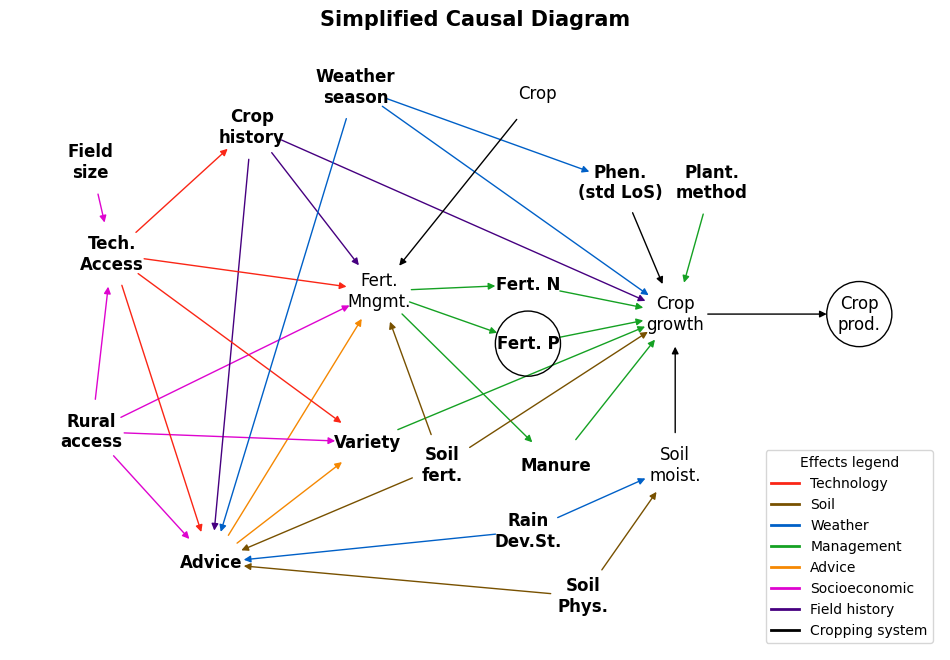

In [30]:
# As some factors are represented by multiple variables (e.g. Variety), 
# we will create a simplified graph that will be the one used when drawing.
edges_to_draw = {(cause.split('_')[0], effect.split('_')[0]) for cause, effect in edges_list}
edges_to_draw = {(cause, effect) for cause, effect in edges_to_draw if cause != effect}
graph_to_draw = nx.DiGraph(edges_to_draw)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

labels={
    'accessibility': 'Rural\naccess', 'crop': 'Crop', 'cropgrowth': 'Crop\ngrowth',
    'fertN': 'Fert. N', 'fertP': 'Fert. P', 'fertilizer': 'Fert.\nMngmt.',
    'fieldsize': 'Field\nsize', 'history': 'Crop\nhistory', 'manure': 'Manure',
    'outcome': 'Crop\nprod.', 'phenology': 'Phen.\n(std LoS)', 'planting': 'Plant.\nmethod',
    'soilfert': 'Soil\nfert.', 'soilmoisture': 'Soil\nmoist.', 'soilpp': 'Soil\nPhys.',
    'technology': 'Tech.\nAccess', 'treat': 'Advice', 'variety': 'Variety',
    'wthseason': 'Weather\nseason', 'wthstage': 'Rain\nDev.St.'
}

edge_colors = []
for cause, effect in graph_to_draw.edges:
    if cause == 'technology':
        edge_colors.append('#fa2616')
    elif cause in ['soilpp', 'soilfert']:
        edge_colors.append('#785100')
    elif cause[:3] == 'wth':
        edge_colors.append('#0060c7')
    elif cause in ('fertN', 'fertP', 'fertilizer', 'manure', 'planting', 'variety'):
        edge_colors.append('#15a123')
    elif cause == 'treat':
        edge_colors.append('#f58802')
    elif cause in ('accessibility', 'fieldsize'):
        edge_colors.append('#de04cf')
    elif cause == 'history':
        edge_colors.append('#460080')
    else:
        edge_colors.append('k')
# We know the adjustment set after the estimand has been identified using the backdoor criteria
adj_set_draw = {
    'history', 'fieldsize', 'phenology', 'soilfert', 'fertP', 'manure', 'treat', 'planting', 'wthstage', 
    'wthseason', 'variety', 'accessibility', 'fertN', 'technology', 'soilpp'
}
pos={
    'accessibility': (-4.24, -0.64), 'crop': (0.6, 4.5), 'cropgrowth': (2.1, 1.15),
    'fertN': (0.5, 1.6), 'fertP': (0.5, 0.7), 'fertilizer': (-1.12, 1.5),
    'fieldsize': (-4.25, 3.46), 'history': (-2.5, 4.0), 'manure': (0.8, -1.15),
    'outcome': (4.1, 1.15), 'phenology': (1.5, 3.15), 'planting': (2.5, 3.15),
    'soilfert': (-0.43, -1.15), 'soilmoisture': (2.1, -1.15), 'soilpp': (1.1, -3.15),
    'technology': (-4.02, 2.06), 'treat': (-2.94, -2.64), 'variety': (-1.24, -.8),
    'wthseason': (-1.37, 4.6), 'wthstage': (.5, -2.15)
}
nx.draw_networkx(
    graph_to_draw, ax=ax, pos=pos, node_size=2200, 
    labels=labels,
    node_shape='o', node_color='#ffffff00', 
    font_weight={node: 'bold' if node in adj_set_draw else 'normal' for node in labels.keys()},
    edge_color=edge_colors,
    edgecolors=['k' if node in ('fertP', 'outcome') else '#FFFFFF00' for node in graph_to_draw.nodes]
)
color_labels = [
    ('#fa2616', 'Technology'), ('#785100', 'Soil'), 
    ('#0060c7', 'Weather'), ('#15a123', 'Management'), 
    ('#f58802', 'Advice'), ('#de04cf', 'Socioeconomic'), 
    ('#460080', 'Field history'), ('k', 'Cropping system'), 
]
ax.legend(handles=[
    mpl.lines.Line2D([], [], color=color, linestyle='-', linewidth=2, label=label)
    for color, label in color_labels
], loc='lower right', title='Effects legend')
ax.set_title('Simplified Causal Diagram', fontweight='bold', fontsize=15)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

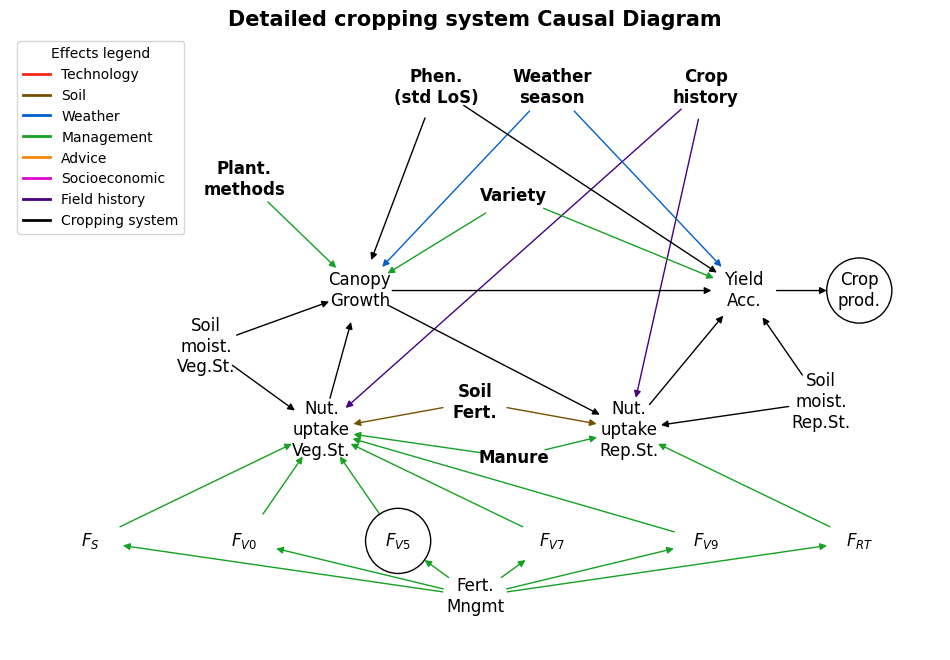

In [158]:
edges_to_draw = {
    (cause, effect) 
    for cause, effect in edges_list 
    if (
        any([v in effect for v in ('cropgrowth', 'outcome')])
        or (('fert' in cause[:4]) and ('fert' in effect[:4]))
    )
}
edges_to_draw = {
    (cause, effect)
    if ('fert' in cause[:4]) or ('cropgrowth' in cause) or ('soilmoist' in cause)
    else (cause.split('_')[0], effect)
    for cause, effect in edges_to_draw
}
edges_to_draw = {(c, e) for c, e in edges_to_draw  if not (('fertP' in c) or ('fertP' in e))}
graph_to_draw = nx.DiGraph(edges_to_draw)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

labels = {
    'cropgrowth_canopy': 'Canopy\nGrowth', 'cropgrowth_nutuprep': 'Nut.\nuptake\nRep.St.',
    'cropgrowth_nutupveg': 'Nut.\nuptake\nVeg.St.', 'cropgrowth_yieldacc': 'Yield\nAcc.',
    'fertN_basal': r'$F_{S}$', 'fertN_emergence': r'$F_{V0}$',
    'fertN_56leaves': r'$F_{V5}$', 'fertN_kneehigh': r'$F_{V7}$', 
    'fertN_810leaves': r'$F_{V9}$', 'fertN_tasselingsilking': r'$F_{RT}$',
    'history': 'Crop\nhistory', 'manure': 'Manure',
    'outcome_prodstd': 'Crop\nprod.', 'phenology': 'Phen.\n(std LoS)',
    'planting': 'Plant.\nmethods', 'soilfert': 'Soil\nFert.',
    'soilmoisture_veg': 'Soil\nmoist.\nVeg.St.', 'soilmoisture_rep': 'Soil\nmoist.\nRep.St.', 
    'variety': 'Variety', 'wthseason': 'Weather\nseason', 
    'fertilizer_management': 'Fert.\nMngmt'
}

pos = {
    'cropgrowth_canopy': (-1.5, 0.5), 'cropgrowth_nutuprep': (2, -2),
    'cropgrowth_nutupveg': (-2, -2), 'cropgrowth_yieldacc': (3.5, .5),
    'fertN_basal': (-5, -4), 'fertN_emergence': (-3, -4),
    'fertN_56leaves': (-1, -4), 'fertN_kneehigh': (1, -4), 
    'fertN_810leaves': (3, -4), 'fertN_tasselingsilking': (5, -4),
    'history': (3., 4.15), 'manure': (.5, -2.5),
    'outcome_prodstd': (5, .5), 'phenology': (-.5, 4.15),
    'planting': (-3., 2.5), 'soilfert': (.0, -1.5),
    'soilmoisture_veg': (-3.5, -.5), 'soilmoisture_rep': (4.5, -1.5),
    'variety': (.5, 2.2), 'wthseason': (1.0, 4.15), 'fertilizer_management': (0, -5)
}

edge_colors = []
for cause, effect in graph_to_draw.edges:
    if cause == 'technology':
        edge_colors.append('#fa2616')
    elif cause in ['soilpp', 'soilfert']:
        edge_colors.append('#785100')
    elif cause[:3] == 'wth':
        edge_colors.append('#0060c7')
    elif cause in ('fertilizer', 'manure', 'planting', 'variety'):
        edge_colors.append('#15a123')
    elif 'fert' in cause:
        edge_colors.append('#15a123')
    elif cause == 'treat':
        edge_colors.append('#f58802')
    elif cause in ('accessibility', 'fieldsize'):
        edge_colors.append('#de04cf')
    elif cause == 'history':
        edge_colors.append('#460080')
    else:
        edge_colors.append('k')

adj_set_draw = { # I know this only after indentifying the effect. Then I add it here
    'variety', 'fertN_tasselingsilking', 'fertN_810leaves', 
    'history', 'fertN_basal', 'manure', 'phenology',  
    'planting', 'history', 'fertN_kneehigh', 'soilfert', 
    'fertN_emergence', 'fertN_56leaves', 'wthseason',
    'technology', 
}
nx.draw_networkx(
    graph_to_draw, ax=ax, pos=pos, node_size=2200, 
    labels=labels,
    node_shape='o', node_color='#ffffff00', 
    font_weight={node: 'bold' if node in adj_set_draw else 'normal' for node in labels.keys()},
    edge_color=edge_colors,
    edgecolors=['k' if node in ('outcome_prodstd', 'fertN_56leaves') else '#FFFFFF00' for node in graph_to_draw.nodes]
)

color_labels = [
    ('#fa2616', 'Technology'), ('#785100', 'Soil'), 
    ('#0060c7', 'Weather'), ('#15a123', 'Management'), 
    ('#f58802', 'Advice'), ('#de04cf', 'Socioeconomic'), 
    ('#460080', 'Field history'), ('k', 'Cropping system'), 
]
ax.legend(handles=[
    mpl.lines.Line2D([], [], color=color, linestyle='-', linewidth=2, label=label)
    for color, label in color_labels
], loc='upper left', title='Effects legend')
ax.set_title('Detailed cropping system Causal Diagram', fontweight='bold', fontsize=15)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

## Validate the node - parent dependency 

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
# # Validate the node-parents dependency  
# results_validate_pd = falsify.validate_pd(causal_graph, data=data_subset.dropna(), adjacent_only=True)
# results_validate_pd = pd.DataFrame.from_dict(
#     results_validate_pd[falsify.FalsifyConst.P_VALUES], 
#     # columns=['pvalue', 'violation'],
# ).T
# results_validate_pd.columns = ['pvalue', 'violation']
# results_validate_pd.index.names = ['node', 'parent']
# # results_validate_pd = results_validate_pd.reset_index().set_index([''])

## Identify effect

In [34]:
fert_df.mean()

fertN_basal               0.387714
fertP_basal               0.333865
fertN_56leaves            0.547208
fertN_810leaves           0.718782
fertN_emergence            0.08934
fertN_kneehigh            0.141117
fertN_tasselingsilking    0.036548
fertP_56leaves             0.11269
fertP_810leaves           0.028426
fertP_emergence            0.06599
fertP_kneehigh            0.005076
fertP_tasselingsilking    0.004061
dtype: object

In [35]:
treatment_name = "fertP_56leaves"
outcome_name = "outcome_prodstd"
model = CausalModel(
   data=data_subset.copy(),
   treatment=treatment_name,
   outcome=outcome_name,
   graph="\n".join(nx.generate_gml(causal_graph))
)

In [36]:
# identified_estimand = model.identify_effect(
#     method_name='exhaustive-search', optimize_backdoor=False,
# )

# print(identified_estimand)

In [37]:
# with open('identified-P56leaves-effect.pkl', 'wb') as f:
#     pickle.dump(identified_estimand, f)

with open('identified-P56leaves-effect.pkl', 'rb') as f:
    identified_estimand = pickle.load(f)
print(identified_estimand)
# # This are the control variables to use in the analysis
adj_set = identified_estimand.backdoor_variables['backdoor']

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
────────────────(E[outcome_prodstd|treat_previousadvice,variety_recycled,field ↪
d[fertP₅₆ₗₑₐᵥₑₛ]                                                               ↪

↪                                                                              ↪
↪ size_value,fertP_tasselingsilking,fertP_810leaves,history_nocrop,fertP_basal ↪
↪                                                                              ↪

↪                                                                              ↪
↪ ,manure_any,soilpp_clay,phenology_losstd,wthseason_srad,planting_handhoe,acc ↪
↪                                                                              ↪

↪                                                                              ↪
↪ essibility_rai,history_maize,fertN_kneehigh,soilfert_oc,planting_ploughsowin

In [38]:
print({i.split('_')[0] for i in adj_set})

{'fertP', 'accessibility', 'fertN', 'wthstage', 'treat', 'fieldsize', 'wthseason', 'soilpp', 'variety', 'planting', 'phenology', 'technology', 'history', 'manure', 'soilfert'}


# Baseline effect estimates


Three types of effects can be estimated. The different effect estimates respond to different questions, and their importance deppend on why we are estimating the effect.

- **ATE**: the average treatment effect. it is the average effect if the entire population were treated versus if the entire population were not. It is useful to answer to the question **What would be the average effect if the entire population were treated?**
- **ATT**: the average treatment effect on the treated. It's the effect on the treated group compared to what would have happened to that same group if they hadn't received the treatment. It reponds to the quesiton **What was the average effect on THOSE THAT RECEIVED the treatment?**, which rephrased could be **What would have happened (on average) if the ones that received the treatmed had not received it?**. This question is important when the effectiveness of the intervention has to be evaluated.
- **ATC**: the average treatment effect on the control group. It's the effect on the control group if they had received the treatment, compared to their actual outcome (not receiving it). It would answer to the question **What would have been the effect of the treatment on those that did not receive the treatment?**


In [39]:
# A df for the ATT and ATE of the different methods
effects_df = pd.DataFrame(
    columns=pd.MultiIndex.from_product([('ate', 'att'), ('value', 'p-value', 'ci-low', 'ci-high')])
)

In [40]:
data_subset_copy = data_subset.copy()
data_subset = data_subset.dropna()

In [41]:
X_df = data_subset[adj_set]
T_series = data_subset[treatment_name].astype(int)
Y_series = data_subset[outcome_name]

# Normalize features
numeric_features = list(X_df.select_dtypes(include='number').columns)
categorical_features = list(set(adj_set) - set(numeric_features))

numeric_transformer = StandardScaler().fit(X_df[numeric_features])
X_df.loc[:, numeric_features] = numeric_transformer.transform(X_df[numeric_features]).astype(np.float32)
X_df[categorical_features] = X_df[categorical_features].astype(np.float32)

transformed_subset = pd.concat([X_df, T_series, Y_series], axis=1)

model._data = transformed_subset.copy()

## No-control Linear Regression

In [42]:
# Assuming no control implies a causal graph with only treatment affecting outcome
causal_graph_nocontrol = nx.DiGraph([(treatment_name, outcome_name)])
model_nocontrol = CausalModel(
   data=data_subset,
   treatment=treatment_name,
   outcome=outcome_name,
   graph="\n".join(nx.generate_gml(causal_graph_nocontrol))
)
identified_estimand_nocontrol = model_nocontrol.identify_effect()

In [43]:
# Estimate ATE
method_name = "backdoor.linear_regression"
nocontrol_ate_estimate = model_nocontrol.estimate_effect(
    identified_estimand_nocontrol, method_name=method_name,
    confidence_intervals=True, target_units='ate',
)
effects_df.loc['No control LR', ('ate', 'value')] = nocontrol_ate_estimate.value
effects_df.loc['No control LR', ('ate', 'p-value')] = nocontrol_ate_estimate.test_stat_significance()['p_value']
effects_df.loc['No control LR', [('ate', 'ci-low'), ('ate', 'ci-high')]] = nocontrol_ate_estimate.get_confidence_intervals()

In [44]:
# Estimate ATT
method_name = "backdoor.linear_regression"
nocontrol_att_estimate = model_nocontrol.estimate_effect(
    identified_estimand_nocontrol, method_name=method_name,
    confidence_intervals=True, target_units='att',
)
effects_df.loc['No control LR', ('att', 'value')] = nocontrol_att_estimate.value
effects_df.loc['No control LR', ('att', 'p-value')] = nocontrol_att_estimate.test_stat_significance()['p_value']
effects_df.loc['No control LR', [('att', 'ci-low'), ('att', 'ci-high')]] = nocontrol_att_estimate.get_confidence_intervals()

## Linear Regression

In [45]:
# Estimate ATE
model._data = transformed_subset.copy()
method_name = "backdoor.linear_regression"
lr_ate_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='ate',
)
effects_df.loc['LR', ('ate', 'value')] = lr_ate_estimate.value
effects_df.loc['LR', ('ate', 'p-value')] = lr_ate_estimate.test_stat_significance()['p_value']
effects_df.loc['LR', [('ate', 'ci-low'), ('ate', 'ci-high')]] = lr_ate_estimate.get_confidence_intervals()

In [46]:
# Estimate ATT
lr_att_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='att',
)
effects_df.loc['LR', ('att', 'value')] = lr_att_estimate.value
effects_df.loc['LR', ('att', 'p-value')] = lr_att_estimate.test_stat_significance()['p_value']
effects_df.loc['LR', [('att', 'ci-low'), ('att', 'ci-high')]] = lr_att_estimate.get_confidence_intervals()

## Propensity Score (PS) matching

The propensity score will be estimated using the Covariance balancin propensity score method. This method generates sample weights for the logistic regression. It aims to have balanced features. The propensity score must change for the different effect estimates to balance the samples in the group they are using for the effect estimation. Therefore, different PS must be calculated for estimating the ATE and the ATT.

### PS estimate

In [51]:
"""
This CBPS algorithm is not working well in specific treatment cases. 
"""
# Create a propensity score DF for the two estimates to consider
ps_df = pd.DataFrame(index=X_df.index)
# for estimand in ('ate', 'att'):
#     tmp_df = X_df.copy()
#     # This converges when all variables are standardized, so we'll do it with the 
#     # all the columns of the df
#     for col in tmp_df.columns:
#         if col == 'crop_maize': # The subset of data used in this analysis is only for Maize
#             tmp_df[col] = 0
#         else:
#             tmp_df[col] = (tmp_df[col] - tmp_df[col].mean())/tmp_df[col].std()
#     cbps = cbpys.CBPS(
#         X=tmp_df.values,
#         W=T_series.values,
#         estimand=estimand.upper(),
#         intercept=True,
#         noi=False,
#         niter=10000
#     )
#     weights = cbps.weights(numpy=True)
#     if estimand == 'att':
#         weights = pd.Series(weights, index=X_df.loc[~T_series.astype(bool)].index)
#         weights = weights.reindex(X_df.index).fillna(1)
    
#     ps_model = LogisticRegression()
#     ps_model = ps_model.fit(X_df, T_series, sample_weight=weights)
    
#     ps_df[f'propensity_score_{estimand}'] = ps_model.predict_proba(X_df)[:,1]

In [49]:
# Functions to evaluate the propensity scores

def get_smd(ps_series, treat_groups=[True, False]):
    '''
    Returns a dataframe with the Standarized Mean Differences for the covariates
    before and after doing the PS matching.
    '''
    tmp_df = X_df.copy()
    tmp_df['propensity_score'] = ps_series
    tmp_df['treat'] = T_series
    tmp_df = tmp_df.loc[(tmp_df.propensity_score >= .2) & (tmp_df.propensity_score <= .8)]
    difs_list = []
    for _, row in tmp_df.loc[T_series.isin(treat_groups)].iterrows():
        comp_row = tmp_df.loc[
            (tmp_df.loc[tmp_df['treat'] != row['treat'], 'propensity_score'] - row['propensity_score']).abs().idxmin()
        ]
        difs_list.append({f: float(row[f]) - float(comp_row[f]) for f in adj_set})
    smd_values = pd.DataFrame({
        'Before Matching': (tmp_df.groupby(tmp_df['treat'])[adj_set].mean().diff().iloc[-1]) / \
                np.sqrt(tmp_df.groupby(tmp_df['treat'])[adj_set].var().mean()),
        'After Matching':
            pd.DataFrame.from_records(difs_list).mean() / 
                np.sqrt(tmp_df.groupby(tmp_df['treat'])[adj_set].var().mean())
    })
    return smd_values.abs()

def evaluate_propensity_scores(ps_series, estimand):
    """
    Creates a plot to evaluate the PS. Makes a histogram to check the common support,
    and the distribution of SMD to check covariate balance.    
    """
    assert estimand.lower() in ('att', 'ate')
    # Evaluate matching ranges
    tmp_df = X_df.copy()
    tmp_df['propensity_score'] = ps_series
    tmp_df = tmp_df.loc[(tmp_df.propensity_score >= .2) & (tmp_df.propensity_score <= .8)]
    print(f'Support: {len(tmp_df)}')
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), width_ratios=(2, 1))
    
    ax = axes[0]
    sns.histplot(
        tmp_df.loc[T_series.astype(bool)],
        x='propensity_score', ax=ax, label='Yes',
        stat ='count', fill=False, element='step', bins=np.linspace(0, 1, 21)
    )
    sns.histplot(
        tmp_df.loc[~T_series.astype(bool)],
        x='propensity_score', ax=ax, label='No',
        stat ='count', fill=False, element='step', bins=np.linspace(0, 1, 21)
    )
    ax.legend(title='Previous advice')
    ax.set_xlim(tmp_df.propensity_score.min(), tmp_df.propensity_score.max()) 
    ax.set_xlabel('Propensity score')
    ax.set_title('Sample common support')

    ax = axes[1]
    if estimand == 'att': 
        treat_groups = [True]
    else:
        treat_groups = [True, False]
    smd_df = get_smd(ps_series, treat_groups)
    sns.stripplot(smd_df, ax=ax)
    ax.set_xticklabels(['Before\nmatching', 'After\nmatching'])
    ax.axhline(0.1, linestyle=':', color='k')
    ax.set_ylabel('SMD')
    ax.set_title('Covariate balance')
    fig.subplots_adjust(wspace=.3)

Support: 174


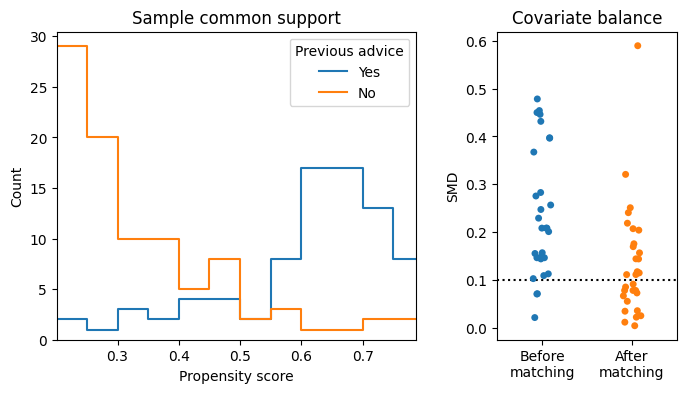

In [57]:
ps_model = LogisticRegression(class_weight={True: 1.2, False: 1})
ps_model = ps_model.fit(X_df, T_series)

ps_df[f'propensity_score_ate'] = ps_model.predict_proba(X_df)[:,1]
evaluate_propensity_scores(ps_df['propensity_score_ate'], 'ate')

Support: 157


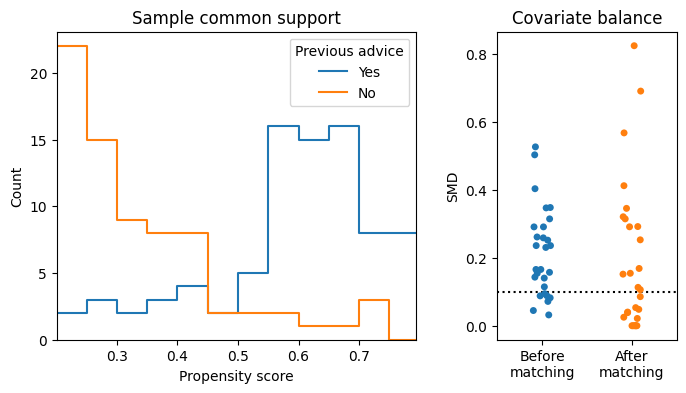

In [64]:
ps_model = LogisticRegression(class_weight={True: 1, False: 1})
ps_model = ps_model.fit(X_df, T_series)

ps_df[f'propensity_score_att'] = ps_model.predict_proba(X_df)[:,1]
evaluate_propensity_scores(ps_df['propensity_score_att'], 'att')

### Estimate effects

In [65]:
# Estimate ATE
model._data = transformed_subset.copy()
model._data['propensity_score'] = ps_df['propensity_score_ate']
model._data = model._data[(model._data.propensity_score >= .2) & (model._data.propensity_score <= .8)]

method_name = "backdoor.propensity_score_matching"
ps_ate_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='ate',
)
effects_df.loc['PS-Matching', ('ate', 'value')] = ps_ate_estimate.value
effects_df.loc['PS-Matching', ('ate', 'p-value')] = ps_ate_estimate.test_stat_significance()['p_value']
effects_df.loc['PS-Matching', [('ate', 'ci-low'), ('ate', 'ci-high')]] = ps_ate_estimate.get_confidence_intervals()

In [66]:
# Estimate ATT
model._data = transformed_subset.copy()
model._data['propensity_score'] = ps_df['propensity_score_att']
model._data = model._data[(model._data.propensity_score >= .2) & (model._data.propensity_score <= .8)]

method_name = "backdoor.propensity_score_matching"
ps_att_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='att',
)
effects_df.loc['PS-Matching', ('att', 'value')] = ps_att_estimate.value
effects_df.loc['PS-Matching', ('att', 'p-value')] = ps_att_estimate.test_stat_significance()['p_value']
effects_df.loc['PS-Matching', [('att', 'ci-low'), ('att', 'ci-high')]] = ps_att_estimate.get_confidence_intervals()

In [67]:
effects_df.astype(float).round(3)

ate                           att                       
               value p-value ci-low ci-high  value p-value ci-low ci-high
No control LR  0.629   0.000  0.448   0.811  0.629   0.000  0.448   0.811
LR             0.051   0.567 -0.308   0.329  0.051   0.567 -0.245   0.334
PS-Matching    0.483   0.031 -0.001   0.897  0.418   0.099 -0.358   1.075

# Causal-ML effect estimates

## Double Machine Learning (DML)

DML makes the following structural equation assumptions on the data generating process:

$$
\begin{split}Y =~& \theta(X) \cdot T + g(X, W) + \epsilon ~~~&~~~ \mathbb{E}[\epsilon | X, W] = 0 \\
T =~& f(X, W) + \eta & \mathbb{E}[\eta \mid X, W] = 0 \\
~& \mathbb{E}[\eta \cdot \epsilon | X, W] = 0\end{split}
$$

What is particularly attractive about DML is that it makes no further structural assumptions on $g$ and $f$ and estimates them non-parametrically using arbitrary non-parametric Machine Learning methods. Our goal is to estimate the constant marginal CATE $\theta(X)$

### First-stage estimators

The first stage estimators are the ones that predict the outcome and treatment based on the confounders and effect modifiers. In this case the whole adjustment set will be used as effect modifiers.

In [68]:
effectmod_features = adj_set 
othernuisance_features = list(set(adj_set) - set(effectmod_features))

XW = X_df.values 
T = T_series.values
Y = Y_series.values
W = X_df[othernuisance_features].values
X = X_df[effectmod_features].values

XW_train, XW_test, Y_train, Y_test, T_train, T_test, \
    fieldid_train, fieldid_test, \
    X_train, X_test, W_train, W_test = train_test_split(
        XW, Y, T, transformed_subset.index,  
        X, W, random_state=24
)

In [69]:
# # Select hyperparameters for outcome model
# parameters = {
#     'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
#     # 'n_estimators': [100, 500, 1000]
# }
# reg = RandomForestRegressor()
# grid_search = GridSearchCV(reg, parameters)
# grid_search.fit(XW_train, Y_train)
# grid_search.best_params_

In [70]:
f_y = RandomForestRegressor(**{'max_depth': 10, 'min_samples_split': 10})
f_y.fit(XW_train, Y_train)
r2_score(y_true=Y_test, y_pred=f_y.predict(XW_test))

In [71]:
# # Select hyperparameters for the treatment model. In this method the treatment model
# # is used as a predictive model.
# parameters = {
#     'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
#     'class_weight': [{True: 1, False: 1}, {True: 3, False: 1}, {True: 5, False: 1}]
# }
# cls = RandomForestClassifier()
# grid_search = GridSearchCV(cls, parameters, scoring='roc_auc')
# grid_search.fit(XW_train, T_train)
# grid_search.best_params_

In [72]:
f_t = RandomForestClassifier(**{'class_weight': {True: 1, False: 1}, 'max_depth': 20, 'min_samples_split': 5})
f_t.fit(XW_train, T_train)
print(classification_report(y_true=T_test, y_pred=f_t.predict(XW_test)))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       217
           1       0.94      0.61      0.74        28

    accuracy                           0.95       245
   macro avg       0.95      0.80      0.86       245
weighted avg       0.95      0.95      0.95       245



### LinearDML

This implements the DML method with a linear function for the last-stage $\theta(X)$

In [73]:
lineardml_est = LinearDML(
    model_y=f_y, 
    model_t=f_t,
    discrete_treatment=True,
    cv=5
)
lineardml_est.fit(
    Y=Y, T=T, X=X, W=W if len(othernuisance_features)>0 else None
)
lineardml_est.score_ # in DML the score is the loss for the last stage

In [74]:
# Estimate ATE
lineardml_ate_estimate = lineardml_est.ate_inference(X)
effects_df.loc['LinearDML', ('ate', 'value')] = lineardml_ate_estimate.mean_point
effects_df.loc['LinearDML', ('ate', 'p-value')] = lineardml_ate_estimate.pvalue()
effects_df.loc['LinearDML', [('ate', 'ci-low'), ('ate', 'ci-high')]] = lineardml_ate_estimate.conf_int_mean()

In [75]:
# Estimate ATT
lineardml_att_estimate = lineardml_est.ate_inference(X[T])
effects_df.loc['LinearDML', ('att', 'value')] = lineardml_att_estimate.mean_point
effects_df.loc['LinearDML', ('att', 'p-value')] = lineardml_att_estimate.pvalue()
effects_df.loc['LinearDML', [('att', 'ci-low'), ('att', 'ci-high')]] = lineardml_att_estimate.conf_int_mean()

### CausalForestDML

This implements DML estimating the last-stage function $\theta(X)$ using causal forest.

In [76]:
cfdml_est = CausalForestDML(
    model_t=f_t, model_y=f_y,
    criterion='het', n_estimators=100,       
    min_samples_leaf=10, max_depth=5, max_samples=0.5,
    discrete_treatment=True, cv=5,
)
cfdml_est.fit(Y, T, X=X, W=W if len(othernuisance_features)>0 else None)
cfdml_est.score_

In [77]:
# Estimate ATE
cfdml_ate_estimate = cfdml_est.ate_inference(X)
effects_df.loc['CausalForestDML', ('ate', 'value')] = cfdml_ate_estimate.mean_point
effects_df.loc['CausalForestDML', ('ate', 'p-value')] = cfdml_ate_estimate.pvalue()
effects_df.loc['CausalForestDML', [('ate', 'ci-low'), ('ate', 'ci-high')]] = cfdml_ate_estimate.conf_int_mean()

In [78]:
# Estimate ATT
cfdml_att_estimate = cfdml_est.ate_inference(X[T])
effects_df.loc['CausalForestDML', ('att', 'value')] = cfdml_att_estimate.mean_point
effects_df.loc['CausalForestDML', ('att', 'p-value')] = cfdml_att_estimate.pvalue()
effects_df.loc['CausalForestDML', [('att', 'ci-low'), ('att', 'ci-high')]] = cfdml_att_estimate.conf_int_mean()

In [79]:
effects_df.astype(float).round(3)

ate                           att                       
                 value p-value ci-low ci-high  value p-value ci-low ci-high
No control LR    0.629   0.000  0.448   0.811  0.629   0.000  0.448   0.811
LR               0.051   0.567 -0.308   0.329  0.051   0.567 -0.245   0.334
PS-Matching      0.483   0.031 -0.001   0.897  0.418   0.099 -0.358   1.075
LinearDML        0.571   0.271 -0.447   1.588  1.143   0.470 -1.957   4.243
CausalForestDML  0.464   0.116 -0.114   1.041  0.511   0.031  0.047   0.975

## Doubly Robust Learning (DRL)


Doubly robust learning follows a similar approach to DML, with three key differences: the first stage outcome model includes the treatment as a predictor, the treatment must be categorical, and it directly uses IPS weighting on the estimate of the potential outcome. Formulation is similar to DML:

$$
\begin{split}Y^{(t)} =~& g_t(X, W) + \epsilon_t ~~~&~~~ E[\epsilon | X, W] = 0 \\
\Pr[T = t | X, W] =~& p_t(X, W) & \\
\{Y^{(t)}\}_{t=1}^{n_t} \perp T | X, W\end{split}
$$

The estimate of the potential outcome is constructed as follows:

$$
Y_{i, t}^{DR} = g_t(X_i, W_i) + \frac{Y_i -g_t(X_i, W_i)}{p_t(X_i, W_i)} \cdot 1\{T_i=t\}
$$

Then, the effect $\theta_t(X)$ can be learn by regressing $Y_{i, t}^{DR} - Y_{i, 0}^{DR}$ on $X_i$. The main advantage of DRL is that the mean squared error of the final estimate $\theta_t(X)$ is only affected by the product of the MSE of the regression estimate $\hat{g}_t(X, W)$ and the PS estimate $\hat{p}_t(X, W)$. Therefore, as long as one of them is accurate then the final model is correct.

### First-stage estimators

For the treatment estimator we will use a estimator different from that used in DML, as the the estimator is seen as a PS estimator, instead of a Treatment predictor. In this case, we want to prioritize covariate balance over prediction accuracy. 

In [80]:
# add treatment to features
XW_train_drl = np.hstack([XW_train, T_train.reshape((-1, 1))])
XW_test_drl = np.hstack([XW_test, T_test.reshape((-1, 1))])

In [81]:
# # Hyperparameter search for regression model
# parameters = {
#     'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
#     # 'n_estimators': [100, 500, 1000]fieldid_train
# }
# reg = RandomForestRegressor()
# grid_search = GridSearchCV(reg, parameters)
# grid_search.fit(XW_train_drl, Y_train)
# grid_search.best_params_

In [82]:
model_regression = RandomForestRegressor(**{'max_depth': 20, 'min_samples_split': 10})
model_regression.fit(XW_train_drl, Y_train)
r2_score(y_true=Y_test, y_pred=model_regression.predict(XW_test_drl))

In [83]:
# # Propensity Score model
# cbps_covs = XW.copy()
# for j in range(cbps_covs.shape[1]):
#     cbps_covs[:, j] = (cbps_covs[:, j] - cbps_covs[:, j].mean())/max(cbps_covs[:, j].std(), 1e-6)
# cbps = cbpys.CBPS(
#     X=cbps_covs,
#     W=T.astype(float),
#     estimand="ATE",
#     intercept=False,
#     noi=False,
#     niter=10000
# )
# weights = cbps.weights(numpy=True)

# model_propensity = Pipeline([('scaler', StandardScaler()), ('logisticregression', LogisticRegression())])
# model_propensity = model_propensity.fit(XW, T, logisticregression__sample_weight=weights)

model_propensity = LogisticRegression(class_weight={True: 3.3, False: 1})
model_propensity = model_propensity.fit(XW, T)
print(classification_report(T, model_propensity.predict(XW)))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       869
           1       0.66      0.84      0.74       111

    accuracy                           0.93       980
   macro avg       0.82      0.89      0.85       980
weighted avg       0.94      0.93      0.94       980



In [84]:
# Check PS values
pd.Series(model_propensity.predict_proba(XW)[:,1]).describe()

count    980.000000
mean       0.184889
std        0.271032
min        0.000021
25%        0.002287
50%        0.037568
75%        0.250537
max        0.986389
dtype: float64

### LinearDRLearner

In [85]:
lineardrl_est = LinearDRLearner(
    model_propensity=model_propensity, model_regression=model_regression,
    cv=5, min_propensity=1e-6
)
lineardrl_est.fit(Y, T, X=X, W=W if len(othernuisance_features)>0 else None)
lineardrl_est.score_

In [86]:
# Estimate ATE
lineardrl_ate_estimate = lineardrl_est.ate_inference(X)
effects_df.loc['LinearDRLearner', ('ate', 'value')] = lineardrl_ate_estimate.mean_point
effects_df.loc['LinearDRLearner', ('ate', 'p-value')] = lineardrl_ate_estimate.pvalue()
effects_df.loc['LinearDRLearner', [('ate', 'ci-low'), ('ate', 'ci-high')]] = lineardrl_ate_estimate.conf_int_mean()

In [87]:
# Estimate ATT
lineardrl_att_estimate = lineardrl_est.ate_inference(X[T])
effects_df.loc['LinearDRLearner', ('att', 'value')] = lineardrl_att_estimate.mean_point
effects_df.loc['LinearDRLearner', ('att', 'p-value')] = lineardrl_att_estimate.pvalue()
effects_df.loc['LinearDRLearner', [('att', 'ci-low'), ('att', 'ci-high')]] = lineardrl_att_estimate.conf_int_mean()

### ForestDRLearner

In [88]:
forestdrl_est = ForestDRLearner(
    model_propensity=model_propensity, model_regression =model_regression,
    n_estimators=100, min_samples_leaf=10, max_depth=5, 
    max_samples=0.5, cv=5, min_propensity=1e-6
)
forestdrl_est.fit(Y, T, X=X, W=W if len(othernuisance_features)>0 else None)
forestdrl_est.score_

In [89]:
# Estimate ATE
forestdrl_ate_estimate = forestdrl_est.ate_inference(X)
effects_df.loc['ForestDRLearner', ('ate', 'value')] = forestdrl_ate_estimate.mean_point
effects_df.loc['ForestDRLearner', ('ate', 'p-value')] = forestdrl_ate_estimate.pvalue()
effects_df.loc['ForestDRLearner', [('ate', 'ci-low'), ('ate', 'ci-high')]] = forestdrl_ate_estimate.conf_int_mean()

In [90]:
# Estimate ATT
forestdrl_att_estimate = forestdrl_est.ate_inference(X[T])
effects_df.loc['ForestDRLearner', ('att', 'value')] = forestdrl_att_estimate.mean_point
effects_df.loc['ForestDRLearner', ('att', 'p-value')] = forestdrl_att_estimate.pvalue()
effects_df.loc['ForestDRLearner', [('att', 'ci-low'), ('att', 'ci-high')]] = forestdrl_att_estimate.conf_int_mean()

In [91]:
effects_df.astype(float).round(3)

ate                           att                       
                 value p-value ci-low ci-high  value p-value ci-low ci-high
No control LR    0.629   0.000  0.448   0.811  0.629   0.000  0.448   0.811
LR               0.051   0.567 -0.308   0.329  0.051   0.567 -0.245   0.334
PS-Matching      0.483   0.031 -0.001   0.897  0.418   0.099 -0.358   1.075
LinearDML        0.571   0.271 -0.447   1.588  1.143   0.470 -1.957   4.243
CausalForestDML  0.464   0.116 -0.114   1.041  0.511   0.031  0.047   0.975
LinearDRLearner  0.442   0.000  0.287   0.597  0.406   0.200 -0.215   1.027
ForestDRLearner  0.257   0.238 -0.169   0.682  0.350   0.045  0.008   0.692

## Meta-Learners

Meta-learners model either two response surfaces, $Y(0)$ and $Y(1)$ separately. They use different approaches for it.

### S-Learner
The S-Learner models $Y(0)$ and $Y(1)$ through one model that receives the treatment assignment $T$ as an input feature (along with the features $X$). The estimated CATE is given by:

$$
\begin{split}\hat{\tau}(x) & = E[Y \mid X=x, T=1] - E[Y\mid X=x, T=0] \\
& = \hat{\mu}(x, 1) - \hat{\mu}(x, 0)\end{split}
$$

where $\hat{\mu}=M(Y \sim (X, T))$ is the outcome model for features $X,T$. Here $M$ is any suitable machine learning algorithm. 

In [92]:
# We will use the same model as that used in DRL
slearner_est = SLearner(
    overall_model=model_regression,
)
# Meta-learners don't allow confidence intervals' estimation, then bootstrap inference
# must be done
slearner_est.fit(Y, T, X=XW, inference=BootstrapInference())

In [93]:
# Estimate ATE
slearner_ate_estimate = slearner_est.ate_inference(X)
effects_df.loc['SLearner', ('ate', 'value')] = slearner_ate_estimate.mean_point
effects_df.loc['SLearner', ('ate', 'p-value')] = slearner_ate_estimate.pvalue()
effects_df.loc['SLearner', [('ate', 'ci-low'), ('ate', 'ci-high')]] = slearner_ate_estimate.conf_int_mean()

In [94]:
# Estimate ATT
slearner_att_estimate = slearner_est.ate_inference(X[T])
effects_df.loc['SLearner', ('att', 'value')] = slearner_att_estimate.mean_point
effects_df.loc['SLearner', ('att', 'p-value')] = slearner_att_estimate.pvalue()
effects_df.loc['SLearner', [('att', 'ci-low'), ('att', 'ci-high')]] = slearner_att_estimate.conf_int_mean()

### First-stage estimators

T-Learner and X-Learner need separate models for $Y(0)$ and $Y(1)$.

In [95]:
# Check, train - test treatment balance
T_train.mean(), T_test.mean() 

In [96]:
# Y(1) model
parameters = {
    'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
    # 'n_estimators': [100, 500, 1000]fieldid_train
}
reg = RandomForestRegressor()
grid_search = GridSearchCV(reg, parameters)
grid_search.fit(XW_train[T_train.astype(bool)], Y_train[T_train.astype(bool)])
grid_search.best_params_

{'max_depth': 20, 'min_samples_split': 10}

In [97]:
f_y1 = RandomForestRegressor(**{'max_depth': 20, 'min_samples_split': 10,})
f_y1.fit(XW_train[T_train.astype(bool)], Y_train[T_train.astype(bool)])
r2_score(y_true=Y_test[T_test.astype(bool)], y_pred=f_y1.predict(XW_test[T_test.astype(bool)]))

In [98]:
# Y(0) model
parameters = {
    'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
    # 'n_estimators': [100, 500, 1000]fieldid_train
}
reg = RandomForestRegressor()
grid_search = GridSearchCV(reg, parameters)
grid_search.fit(XW_train[~T_train.astype(bool)], Y_train[~T_train.astype(bool)])
grid_search.best_params_

{'max_depth': 5, 'min_samples_split': 20}

In [99]:
f_y0 = RandomForestRegressor(**{'max_depth': 20, 'min_samples_split': 10})
f_y0.fit(XW_train[~T_train.astype(bool)], Y_train[~T_train.astype(bool)])
r2_score(y_true=Y_test[~T_test.astype(bool)], y_pred=f_y0.predict(XW_test[~T_test.astype(bool)]))

### T-Learner
The T-Learner models $Y(0)$, $Y(1)$ separately. The estimated CATE is given by:

$$
\begin{split}\hat{\tau}(x) & = E[Y(1)-Y(0)\mid X=x] \\
            & = E[Y(1)\mid X=x] - E[Y(0)\mid X=x] \\
            & = \hat{\mu}_1(x) - \hat{\mu}_0(x)\end{split}
$$

Where, $\hat{\mu}_0 = M_0(Y^0\sim X^0),\; \hat{\mu}_1 = M_1(Y^1\sim X^1)$ are the outcome models for the control and treatment group, respectively. Here, $M_0$, $M_1$ can be any suitable machine learning algorithms that can learn the relationship between features and outcome.

In [100]:
tlearner_est = TLearner(
    models=(f_y0, f_y1),
)
tlearner_est.fit(Y, T, X=XW, inference=BootstrapInference())

In [101]:
# Estimate ATE
tlearner_ate_estimate = tlearner_est.ate_inference(X)
effects_df.loc['TLearner', ('ate', 'value')] = tlearner_ate_estimate.mean_point
effects_df.loc['TLearner', ('ate', 'p-value')] = tlearner_ate_estimate.pvalue()
effects_df.loc['TLearner', [('ate', 'ci-low'), ('ate', 'ci-high')]] = tlearner_ate_estimate.conf_int_mean()

In [102]:
# Estimate ATT
tlearner_att_estimate = tlearner_est.ate_inference(X[T])
effects_df.loc['TLearner', ('att', 'value')] = tlearner_att_estimate.mean_point
effects_df.loc['TLearner', ('att', 'p-value')] = tlearner_att_estimate.pvalue()
effects_df.loc['TLearner', [('att', 'ci-low'), ('att', 'ci-high')]] = tlearner_att_estimate.conf_int_mean()

### X-Learner

In [103]:
xlearner_est = XLearner(
    models=(f_y0, f_y1),
    propensity_model=model_propensity, # Same as used in DRL
)
xlearner_est.fit(Y, T, X=XW, inference=BootstrapInference())

In [104]:
# Estimate ATE
xlearner_ate_estimate = xlearner_est.ate_inference(X)
effects_df.loc['XLearner', ('ate', 'value')] = xlearner_ate_estimate.mean_point
effects_df.loc['XLearner', ('ate', 'p-value')] = xlearner_ate_estimate.pvalue()
effects_df.loc['XLearner', [('ate', 'ci-low'), ('ate', 'ci-high')]] = xlearner_ate_estimate.conf_int_mean()

In [105]:
# Estimate ATT
xlearner_att_estimate = xlearner_est.ate_inference(X[T])
effects_df.loc['XLearner', ('att', 'value')] = xlearner_att_estimate.mean_point
effects_df.loc['XLearner', ('att', 'p-value')] = xlearner_att_estimate.pvalue()
effects_df.loc['XLearner', [('att', 'ci-low'), ('att', 'ci-high')]] = xlearner_att_estimate.conf_int_mean()

## Effects summary

In [106]:
effects_df.astype(float).round(3)

ate                           att                       
                 value p-value ci-low ci-high  value p-value ci-low ci-high
No control LR    0.629   0.000  0.448   0.811  0.629   0.000  0.448   0.811
LR               0.051   0.567 -0.308   0.329  0.051   0.567 -0.245   0.334
PS-Matching      0.483   0.031 -0.001   0.897  0.418   0.099 -0.358   1.075
LinearDML        0.571   0.271 -0.447   1.588  1.143   0.470 -1.957   4.243
CausalForestDML  0.464   0.116 -0.114   1.041  0.511   0.031  0.047   0.975
LinearDRLearner  0.442   0.000  0.287   0.597  0.406   0.200 -0.215   1.027
ForestDRLearner  0.257   0.238 -0.169   0.682  0.350   0.045  0.008   0.692
SLearner         0.359   0.274 -0.284   1.002  0.883   0.053 -0.011   1.778
TLearner         0.453   0.335 -0.468   1.374  1.359   0.001  0.529   2.189
XLearner         0.426   0.230 -0.269   1.122  0.723   0.011  0.166   1.280

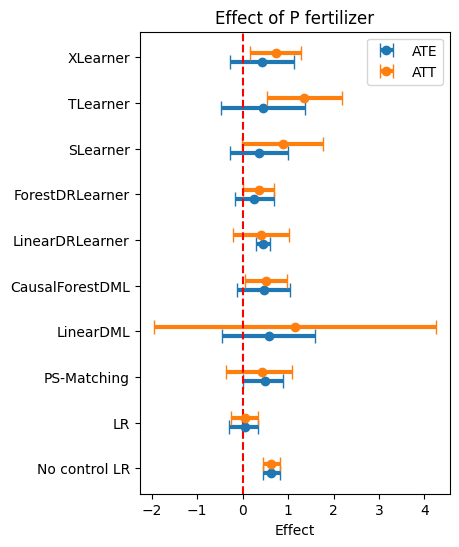

In [107]:
fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharex=True, sharey=True)
for n, est in enumerate(('ate', 'att')):
    lower_error = effects_df[(est, 'value')] - effects_df[(est, 'ci-low')]
    upper_error = effects_df[(est, 'ci-high')] - effects_df[(est, 'value')]
    asymmetric_error = [lower_error, upper_error]
    y_pos = np.arange(len(effects_df.index))
    y_pos = y_pos - (0.1, -.1)[n]
    ax.errorbar(
        x=effects_df[(est, 'value')],
        y=y_pos,
        xerr=asymmetric_error,
        fmt='o',
        color=('#1f77b4', '#ff7f0e')[n],
        ecolor=('#1f77b4', '#ff7f0e')[n],
        elinewidth=3,
        capsize=5,
        linestyle='',
        label=est.upper()
    )
ax.axvline(0, linestyle='--', color='r')
ax.set_yticks(np.arange(len(effects_df.index)))
ax.set_yticklabels(effects_df.index)
ax.set_xlabel('Effect')
ax.set_title('Effect of P fertilizer')
ax.legend()

# Refute ATE estimates

We will use the dowhy refutation tests. To do that, we need to create the ATE estimate using dowhy.

In [108]:
ate_estimates_dict = {
    'No control LR': nocontrol_ate_estimate,
    'LR': lr_ate_estimate,
    'PS-Matching': ps_ate_estimate
}

In [109]:
# We have to create dowhy-based estimates for the CausalML estimators for that
# we need to pass the parameters we used to fit the models
init_params_dict = {
    'LinearDML': dict(model_y=f_y, model_t=f_t, discrete_treatment=True, cv=5), 
    'CausalForestDML': dict(model_t=f_t, model_y=f_y, criterion='het', n_estimators=100, 
                            min_samples_leaf=10, max_depth=5, max_samples=0.5, 
                            discrete_treatment=True, cv=5),
    'LinearDRLearner': dict(model_propensity=model_propensity, model_regression=model_regression,
                            cv=5, min_propensity=1e-6), 
    'ForestDRLearner': dict(model_propensity=model_propensity, model_regression=model_regression,
                            n_estimators=100, min_samples_leaf=10, max_depth=5, max_samples=0.5, 
                            cv=5, min_propensity=1e-6), 
    'SLearner': dict(overall_model=model_regression), 
    'TLearner': dict(models=(f_y0, f_y1)),
    'XLearner': dict(models=(f_y0, f_y1), propensity_model=model_propensity)
}
method_names_dict = {
    'LinearDML': 'backdoor.econml.dml.LinearDML', 
    'CausalForestDML': 'backdoor.econml.dml.CausalForestDML',
    'LinearDRLearner': 'backdoor.econml.dr.LinearDRLearner', 
    'ForestDRLearner': 'backdoor.econml.dr.ForestDRLearner', 
    'SLearner': 'backdoor.econml.metalearners.SLearner', 
    'TLearner': 'backdoor.econml.metalearners.TLearner',
    'XLearner': 'backdoor.econml.metalearners.XLearner'
}
fit_params_dict = { # We don't need inference for the refutation tests
    # 'SLearner': dict(inference=BootstrapInference()), 
    # 'TLearner': dict(inference=BootstrapInference()),
    # 'XLearner': dict(inference=BootstrapInference())
    'LinearDML': {'cache_values': True},
    'CausalForestDML': {'cache_values': True},
    'LinearDRLearner': {'cache_values': True},
    'ForestDRLearner': {'cache_values': True},
}

In [110]:
# dowhy ATE estimates for causal ML estimators
model._data = transformed_subset.copy()

for estimate_name in tqdm(init_params_dict.keys()):
    ate_estimates_dict[estimate_name] = model.estimate_effect(
        identified_estimand, method_name=method_names_dict[estimate_name],
        confidence_intervals=False, target_units='ate', effect_modifiers=effectmod_features,
        method_params={
            'init_params': init_params_dict[estimate_name],
            'fit_params': fit_params_dict.get(estimate_name, {})
        }
    )

  0%|          | 0/7 [00:00<?, ?it/s]

In [111]:
import copy
ate_estimates_dict['LinearDML']._estimator_object = copy.deepcopy(lineardml_est)
ate_estimates_dict['CausalForestDML']._estimator_object = copy.deepcopy(cfdml_est)
ate_estimates_dict['LinearDRLearner']._estimator_object = copy.deepcopy(lineardml_est)
ate_estimates_dict['ForestDRLearner']._estimator_object = copy.deepcopy(forestdrl_est)

In [112]:
ate_estimates_dict['LinearDML'].value = lineardml_est.ate(X)
ate_estimates_dict['CausalForestDML'].value = cfdml_est.ate(X)
ate_estimates_dict['LinearDRLearner'].value = lineardml_est.ate(X)
ate_estimates_dict['ForestDRLearner'].value = forestdrl_est.ate(X)

## Placebo

Change the treatment for a randomly-generated placebo variable. The new effect must be zero.

In [113]:
# # Run placebo test for all estimates
# ate_placebo_refuter_results = {}
# for estimate_name, estimate in ate_estimates_dict.items():
#     if estimate_name in ate_placebo_refuter_results:
#         continue
#     res_refuter = model.refute_estimate(
#         identified_estimand, estimate,
#         method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute",
#         n_jobs=12
#     )
#     ate_placebo_refuter_results[estimate_name] = res_refuter

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimator.py:266: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_effect_mods = data.groupby(effect_modifier_names)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mo

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

In [114]:
# refute_ate_results = pd.DataFrame.from_dict(
#     {
#         k: (v.estimated_effect, v.new_effect, v.refutation_result['p_value'])
#         for k, v in ate_placebo_refuter_results.items()
#     }, 
#     orient='index', 
#     columns=pd.MultiIndex.from_product([('placebo_treatment',), ('estimated_effect', 'new_effect', 'p-value')])
# )    

In [115]:
# refute_ate_results.to_pickle('data/refute_ate_results_p56leaves.pkl')
refute_ate_results = pd.read_pickle('data/refute_ate_results_p56leaves.pkl')

## Random common cause

Adds a randomly generated confounder. The new effect must be similar to the estimated effect.

In [116]:
# # Run random common cause test for all estimates
# ate_randomcommoncause_refuter_results = {}
# for estimate_name, estimate in ate_estimates_dict.items():
#     if estimate_name in ate_randomcommoncause_refuter_results:
#         continue
#     res_refuter = model.refute_estimate(
#         identified_estimand, estimate,
#         method_name="random_common_cause", show_progress_bar=True,
#         n_jobs=16
#     )
#     ate_randomcommoncause_refuter_results[estimate_name] = res_refuter

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimator.py:266: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_effect_mods = data.groupby(effect_modifier_names)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

In [117]:
# refute_ate_results = refute_ate_results.join(pd.DataFrame.from_dict(
#     {
#         k: (v.estimated_effect, v.new_effect, v.refutation_result['p_value'])
#         for k, v in ate_randomcommoncause_refuter_results.items()
#     }, 
#     orient='index', 
#     columns=pd.MultiIndex.from_product([('random_common_cofounder',), ('estimated_effect', 'new_effect', 'p-value')])
# ))

In [118]:
# refute_ate_results.to_pickle('data/refute_ate_results_p56leaves.pkl')
refute_ate_results = pd.read_pickle('data/refute_ate_results_p56leaves.pkl')
# refute_ate_results

## Remove random subset

In [119]:
# # Run random common cause test for all estimates
# ate_datasubset_refuter_results = {}
# for estimate_name, estimate in ate_estimates_dict.items():
#     if estimate_name in ate_datasubset_refuter_results:
#         continue
#     res_refuter = model.refute_estimate(
#         identified_estimand, estimate,
#         method_name="data_subset_refuter", show_progress_bar=True,
#         n_jobs=12
#     )
#     ate_datasubset_refuter_results[estimate_name] = res_refuter

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimator.py:266: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_effect_mods = data.groupby(effect_modifier_names)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will b

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was pass

In [121]:
# refute_ate_results = refute_ate_results.join(pd.DataFrame.from_dict(
#     {
#         k: (v.estimated_effect, v.new_effect, v.refutation_result['p_value'])
#         for k, v in ate_datasubset_refuter_results.items()
#     }, 
#     orient='index', 
#     columns=pd.MultiIndex.from_product([('data_subset_refuter',), ('estimated_effect', 'new_effect', 'p-value')])
# ))

In [150]:
# refute_ate_results.to_pickle('data/refute_ate_results_p56leaves.pkl')
refute_ate_results = pd.read_pickle('data/refute_ate_results_p56leaves.pkl')
refute_ate_results.round(3)

placebo_treatment                    random_common_cofounder  \
                 estimated_effect new_effect p-value        estimated_effect   
No control LR               0.629      0.001    0.96                   0.629   
LR                          0.051     -0.006    0.92                   0.051   
PS-Matching                 0.483      0.004    0.86                   0.483   
LinearDML                   0.571      0.013    0.78                   0.571   
CausalForestDML             0.464      0.000    0.98                   0.464   
LinearDRLearner             0.571      0.039    0.78                   0.571   
ForestDRLearner             0.257      0.019    0.74                   0.257   
SLearner                    0.401      0.006    0.82                   0.401   
TLearner                    0.435      0.013    0.92                   0.435   
XLearner                    0.440     -0.002    0.94                   0.440   

                                   data_subset_refuter                     
                new_effect p-value    estimated_effect new_effect p-value  
No control LR        0.352    0.00               0.629      0.347    0.00  
LR                   0.051    1.00               0.051      0.093    0.70  
PS-Matching          0.602    0.02               0.483      0.438    0.54  
LinearDML            0.646    0.82               0.571      0.682    0.74  
CausalForestDML      0.395    0.16               0.464      0.406    0.48  
LinearDRLearner      0.338    0.02               0.571      0.200    0.10  
ForestDRLearner      0.339    0.30               0.257      0.307    0.68  
SLearner             0.363    0.16               0.401      0.361    0.66  
TLearner             0.452    0.40               0.435      0.459    0.94  
XLearner             0.412    0.24               0.440      0.423    0.80

## Sensitivity to unobserved common cause

In [124]:
# """
# The dowhy implementations of the non-parametric sensitivity analysis is not numerically stable.
# It is not yielding results in this case.
# """
# # # Run sensitivity analysis for baseline and Meta-Learners estimates
# ate_unobservedcommoncause_refuter_results = {}
# for estimate_name in ['LR', 'PS-Matching', 'SLearner', 'TLearner', 'XLearner']:
#     estimate = ate_estimates_dict[estimate_name]
#     if estimate_name in ate_unobservedcommoncause_refuter_results:
#         continue
#     if estimate_name == 'No control LR':
#         continue # There are no common-causes when no control is considered
#     res_refuter = model.refute_estimate(
#         identified_estimand, estimate,
#         method_name="add_unobserved_common_cause",
#         simulation_method="non-parametric-partial-R2", # This is as described in Chernozhukov et al (2022)
#         partial_r2_confounder_treatment = np.arange(0, 0.11, 0.01),
#         partial_r2_confounder_outcome = np.arange(0, 0.11, 0.01),
#         plotmethod=None
#     )
#     ate_unobservedcommoncause_refuter_results[estimate_name] = res_refuter.results.iloc[:, 4:].iloc[0].to_dict()
#     ate_unobservedcommoncause_refuter_results[estimate_name]['rv'] = res_refuter.RV
#     ate_unobservedcommoncause_refuter_results[estimate_name]['rv_alpha'] = res_refuter.RV_alpha

In [125]:
# Sensitivity analysis for the DML and RDL estimates
econml_estimates_dict = {
    'LinearDML': lineardml_est, 'CausalForestDML': cfdml_est, 
    'LinearDRLearner': lineardrl_est, 'ForestDRLearner': forestdrl_est, 
    # 'SLearner': slearner_est, 'TLearner': tlearner_est, 'XLearner': xlearner_est
}

for estimate_name, estimate in econml_estimates_dict.items():
    kwargs = dict(c_y=.10, c_t=.10)
    if 'DRL' in estimate_name:
        kwargs['T'] = 1
    ate_unobservedcommoncause_refuter_results[estimate_name] = pd.DataFrame(
        estimate.sensitivity_summary(**kwargs).tables[0],
        columns=['lower_confidence_bound', 'lower_ate_bound', 'ate', 'upper_ate_bound', 'upper_confidence_bound']
    ).iloc[1].map(lambda x: x.data).to_dict()
    ate_unobservedcommoncause_refuter_results[estimate_name]['rv'] = estimate.sensitivity_summary(**kwargs).tables[1][1][0].data
    ate_unobservedcommoncause_refuter_results[estimate_name]['rv_alpha'] = estimate.sensitivity_summary(**kwargs).tables[1][1][1].data

In [126]:
sensitivity_ate_results = pd.DataFrame.from_dict(ate_unobservedcommoncause_refuter_results, orient='index')
sensitivity_ate_results['ate'] = sensitivity_ate_results.ate.fillna(effects_df[('ate', 'value')])
sensitivity_ate_results.to_pickle('data/sensitivity_ate_results_p56leaves.pkl')
sensitivity_ate_results= pd.read_pickle('data/sensitivity_ate_results_p56leaves.pkl')
sensitivity_ate_results

,lower_ate_bound,upper_ate_bound,lower_confidence_bound,upper_confidence_bound,rv,rv_alpha,ate
LR,NaN,NaN,NaN,NaN,0.990,0.990,0.050760
PS-Matching,0.352756,0.613345,0.118193,0.817357,0.330,0.170,0.483051
SLearner,NaN,NaN,NaN,NaN,0.990,0.990,0.358937
TLearner,NaN,NaN,NaN,NaN,0.990,0.990,0.452890
XLearner,NaN,NaN,NaN,NaN,0.990,0.990,0.426289
LinearDML,-0.062000,0.848000,-0.366000,1.127000,0.087,0.024,0.393000
CausalForestDML,-0.066000,0.852000,-0.380000,1.138000,0.086,0.021,0.393000
LinearDRLearner,-2.805000,3.689000,-3.238000,4.097000,0.014,0.009,0.442000
ForestDRLearner,-2.865000,3.439000,-3.262000,3.824000,0.010,0.003,0.287000


# Heterogeneous effects

In [127]:
def get_x(feature):
    return X[:, effectmod_features.index(feature)]

In [128]:
econml_estimates_dict = {
    'LinearDML': lineardml_est, 'CausalForestDML': cfdml_est, 
    'LinearDRLearner': lineardrl_est, 'ForestDRLearner': forestdrl_est, 
    'SLearner': slearner_est, 'TLearner': tlearner_est, 'XLearner': xlearner_est
}
individual_effects = pd.DataFrame(index=X_df.index)
for estimate_name, estimate in tqdm(econml_estimates_dict.items(), total=len(econml_estimates_dict)):
    individual_effects[(estimate_name, 'mean')] = estimate.effect(X)
    individual_effects[[(estimate_name, 'ci-low'), (estimate_name, 'ci-high')]] = np.array(estimate.effect_interval(X)).T
individual_effects.columns = pd.MultiIndex.from_tuples(individual_effects.columns)

  0%|          | 0/7 [00:00<?, ?it/s]

## Difference in effects

### How correlated are the effects?

Text(0.5, 1.0, 'Correlation between different effect estimates')

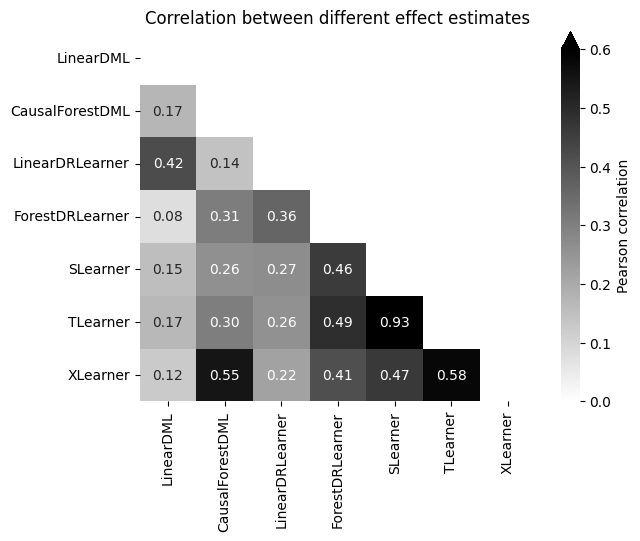

In [129]:
# Correlation matrix
fig, ax = plt.subplots(1, 1)
effect_cor = individual_effects.loc[:, (slice(None), 'mean')].corr().droplevel(1, axis=0).droplevel(1, axis=1)
sns.heatmap(
    effect_cor, annot=True, ax=ax,
    mask=np.triu(np.ones_like(effect_cor)),
    vmin=0, vmax=.6, fmt=".2f", cmap='gray_r',
    cbar_kws=dict(label='Pearson correlation', extend='max')
)
ax.set_title('Correlation between different effect estimates')

### How different are the effects?

Text(0.5, 1.0, 'Average absolute difference in effects')

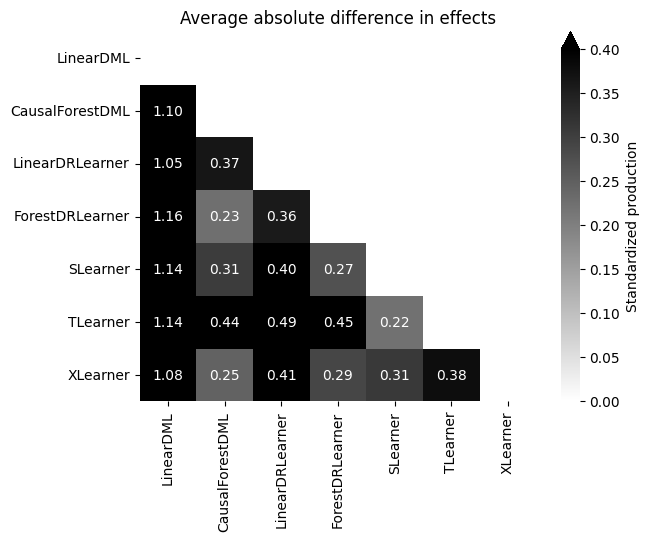

In [130]:
# Average difference of effects
effects_array = individual_effects.loc[:, (slice(None), 'mean')].to_numpy()
effect_diff = effects_array[:, :, np.newaxis] - effects_array[:, np.newaxis, :]
effect_diff = np.abs(effect_diff).mean(axis=0)
effect_diff = pd.DataFrame(effect_diff, index=effect_cor.index, columns=effect_cor.columns)
fig, ax = plt.subplots(1, 1)
sns.heatmap(
    effect_diff, ax=ax,
    annot=True, mask=np.triu(np.ones_like(effect_cor)),
    vmin=0, vmax=.4, fmt=".2f", cmap='gray_r',
    cbar_kws=dict(label='Standardized production', extend='max')
)
ax.set_title('Average absolute difference in effects')

### Are the effects pointing to the same conclusion?

Text(0.5, 1.0, 'Proportion of agreement when the\ncritical threshold is 0.20')

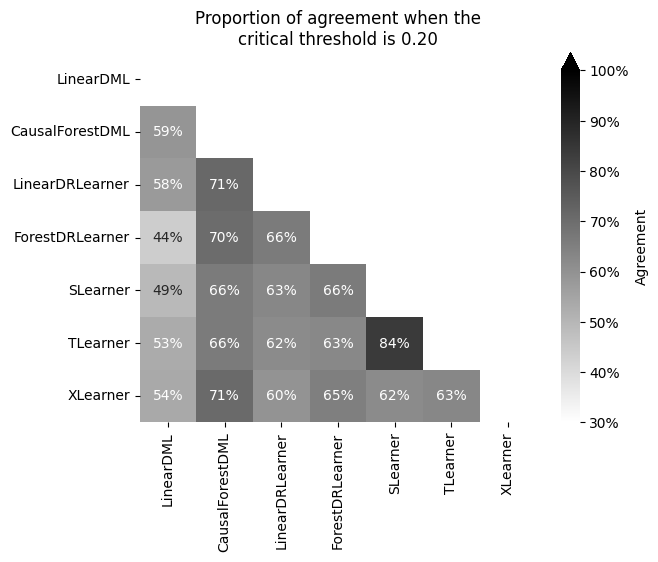

In [131]:
# Here we produce an effect agreement matrix. The idea is that if the CATE model estimates
# an effect above or below some significant threshold, then we can say that there is a 
# significantly positive or negative effect. The idea is the show how much the different
# models agree on that regard.
significant_effect_threshold = .2
states_array = np.sign(effects_array) * (np.abs(effects_array) > significant_effect_threshold)
agreed_mask = states_array[:, :, np.newaxis] == states_array[:, np.newaxis, :]
effect_agreement = agreed_mask.mean(axis=0)
effect_agreement = pd.DataFrame(
    effect_agreement, 
    index=effect_cor.index, columns=effect_cor.columns
)
fig, ax = plt.subplots(1, 1)
ax = sns.heatmap(
    effect_agreement, 
    annot=True, mask=np.triu(np.ones_like(effect_cor)),
    vmin=0.3, vmax=1, fmt=".0%", cmap='gray_r',
    cbar_kws=dict(
        label='Agreement', extend='max', 
        format=mpl.ticker.PercentFormatter(xmax=1.0, decimals=0)
    )
)
ax.set_title(f'Proportion of agreement when the\ncritical threshold is {significant_effect_threshold:.2f}')

### What could be driving the difference in effects?

Permutaiton feature importance analysis is used to analyze how the features drive the average mean difference in effects. The idea is to see if the features of the CATE model influences the difference in estimates.

In [132]:
tmp_df = X_df.copy()
(tmp_df - tmp_df.mean())/tmp_df.std()
tmp_df = tmp_df[sorted(tmp_df.columns)]
tmp_df['effect_mean_diff'] = np.abs((effects_array[:, :, np.newaxis] - effects_array[:, np.newaxis, :])).mean(axis=(1,2))

tmp_x_train, tmp_x_test, tmp_y_train, tmp_y_test = train_test_split(
    tmp_df.iloc[:,:-1], tmp_df.iloc[:,-1], random_state=32
)
effectdiff_reg = GradientBoostingRegressor(max_depth=5, min_samples_leaf=10)

kf = KFold(n_splits=5, shuffle=True)
print(cross_val_score(effectdiff_reg, tmp_x_train, tmp_y_train, cv=kf, scoring='r2'))
effectdiff_reg.fit(tmp_x_train, tmp_y_train)
r2_score(tmp_y_test, effectdiff_reg.predict(tmp_x_test))

[-0.00433083  0.02746829  0.0937292   0.12664893 -0.08564081]


count    980.000000
mean       0.483097
std        0.465716
min        0.060544
25%        0.289931
50%        0.394328
75%        0.532127
max        6.435284
Name: effect_mean_diff, dtype: float64

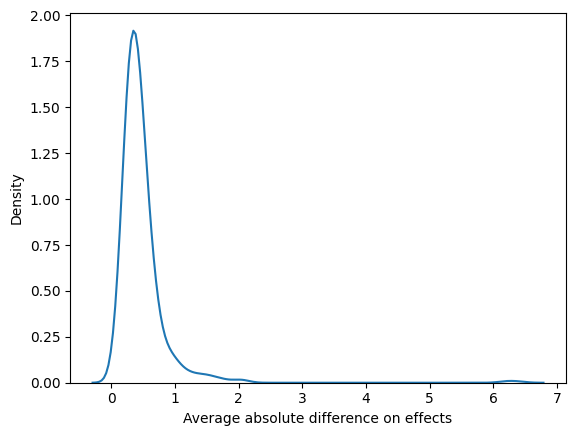

In [133]:
fig, ax = plt.subplots(1, 1)
sns.kdeplot(
    tmp_df['effect_mean_diff']
)
ax.set_xlabel('Average absolute difference on effects')
tmp_df['effect_mean_diff'].describe()

In [134]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    estimator=effectdiff_reg, X=tmp_x_test, y=tmp_y_test,
    n_repeats=10, n_jobs=-1, scoring='r2'           
)

Text(0.5, 1.0, 'Key Drivers of Disagreement Between Effect Estimators')

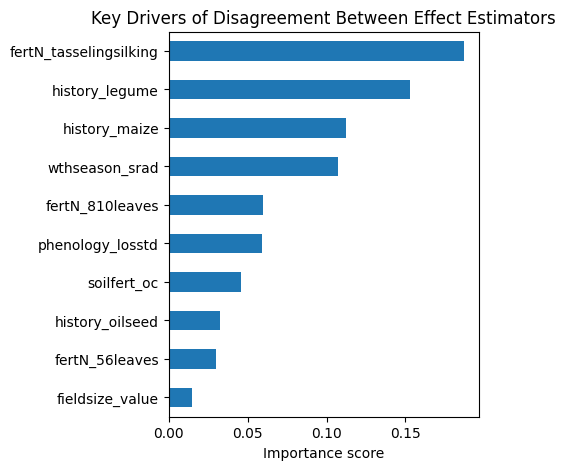

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
pd.Series(
    importance_result['importances_mean'], index=tmp_df.columns[:-1]
).sort_values()[-10:].plot.barh(ax=ax)
ax.set_xlabel('Importance score')
ax.set_title('Key Drivers of Disagreement Between Effect Estimators')

## CATE model evaluation
The DRTester class implements Best Linear Predictor (BLP), calibration r-squared, and uplift modeling methods for validation.

- The Calibration R-squared is a measure of effect size. It answers the question, "How much of the variation in the true CATEs is my model explaining?"
- The CATE Best Linear Predictor (BLP) test is a hypothesis test. It answers the question, "Is the variation my model is explaining statistically significant, or could it just be random noise?"
- The Qini and AUTOC metrics evaluate your CATE model by asking a simple question: "Does my model's ranking of individuals by their predicted effect actually correspond to their true effect?"

In [136]:
def run_dr_cate_tests(est):
    tester = DRTester(
        model_regression=model_regression,
        model_propensity=model_propensity,
        cate=est
    ).fit_nuisance(X_test, T_test, Y_test, X_train, T_train, Y_train)
    
    res = tester.evaluate_all(X_test, X_train)
    return res.summary().iloc[0].to_dict()

In [137]:
cate_evaluation_results = {}
for estimate_name, estimate in tqdm(econml_estimates_dict.items(), total=len(econml_estimates_dict)):
    cate_evaluation_results[estimate_name] = run_dr_cate_tests(estimate)
cate_evaluation_results = pd.DataFrame.from_dict(cate_evaluation_results, orient='index')

  0%|          | 0/7 [00:00<?, ?it/s]

In [138]:
cate_evaluation_results

,treatment,blp_est,blp_se,blp_pval,qini_est,qini_se,qini_pval,autoc_est,autoc_se,autoc_pval,cal_r_squared
LinearDML,1.0,0.116,0.109,0.289,0.079,0.030,0.005,0.161,0.103,0.059,-1.523
CausalForestDML,1.0,2.954,1.592,0.065,0.131,0.110,0.116,0.510,0.520,0.163,0.407
LinearDRLearner,1.0,1.248,0.427,0.004,0.191,0.075,0.006,0.513,0.203,0.006,0.425
ForestDRLearner,1.0,3.849,1.842,0.038,0.151,0.045,0.000,0.279,0.105,0.004,-0.059
SLearner,1.0,2.081,0.545,0.000,0.199,0.052,0.000,0.521,0.140,0.000,0.218
TLearner,1.0,1.567,0.427,0.000,0.237,0.028,0.000,0.614,0.103,0.000,0.539
XLearner,1.0,1.377,0.646,0.034,0.118,0.047,0.006,0.342,0.139,0.007,0.243


In [139]:
cate_evaluation_ranked = pd.DataFrame(index=cate_evaluation_results.index)
cate_evaluation_ranked['blp'] = (cate_evaluation_results.blp_est-1).abs().rank().astype(int)
cate_evaluation_ranked['qini'] = cate_evaluation_results.qini_est.rank(ascending=False).astype(int)
cate_evaluation_ranked['cal_r2'] = cate_evaluation_results.cal_r_squared.rank(ascending=False).astype(int)
cate_evaluation_ranked['rank_sum'] = cate_evaluation_ranked.sum(axis=1)
cate_evaluation_ranked.sort_values(by='rank_sum')

,blp,qini,cal_r2,rank_sum
TLearner,3,1,1,5
LinearDRLearner,1,3,2,6
SLearner,5,2,5,12
XLearner,2,6,4,12
CausalForestDML,6,5,3,14
ForestDRLearner,7,4,6,17
LinearDML,4,7,7,18


### Analyze a practical case with the best CATE model

First we will look at how the different features affect the CATE function using SHAP values.

In [140]:
import shap
shap_values = tlearner_est.shap_values(X)

PermutationExplainer explainer: 981it [02:07,  7.56it/s]                                                                  


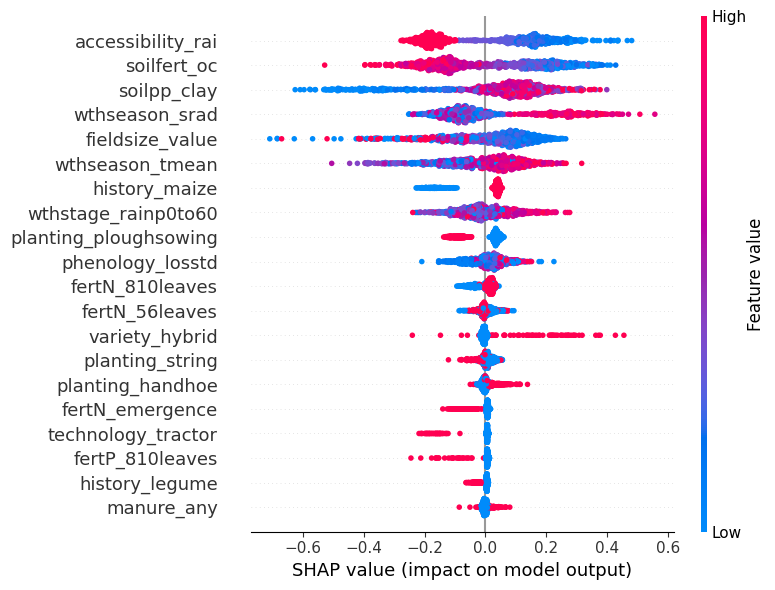

In [141]:
shap.summary_plot(shap_values['Y0']['T0_1'], feature_names=X_df.columns, plot_size=(8, 6))

### Plots of 2 Variable interaction

In [142]:
def plot_2d_cate(varx, vary, labelx, labely, est, ax,
                 domain_width=5., nbins=10, vmin=-.3, vmax=.3,):
    '''
    Plots CATE conditional on two variables. Variables are continous and centered around 
    zero. 
    
    '''
    perc_list = np.linspace(-domain_width/2, domain_width/2, nbins+1)
    dp = (max(perc_list)-min(perc_list))/(len(perc_list)-1)
    
    cate_mean = np.zeros(shape=(len(perc_list), len(perc_list)))
    cate_std = np.zeros_like(cate_mean)
    cate_pvalue = np.zeros_like(cate_mean)
    
    xx, yy = np.meshgrid(perc_list, perc_list)
    ii, jj = np.indices(xx.shape)
    for i, j in zip(ii.flatten(), jj.flatten()):
        x = xx[i][j]; y = yy[i][j]
        x_low = x - dp/2; x_high = x + dp/2
        if x == min(perc_list): x_low = -99.
        if x == max(perc_list): x_high = 99.
        y_low = y - dp/2; y_high = y + dp/2
        if y == min(perc_list): y_low = -99.
        if y == max(perc_list): y_high = 99.
        
        condition = (
            X_df[varx].map(lambda x: x_low <= x < x_high) &
            X_df[vary].map(lambda y: y_low <= y < y_high) 
        )
        if condition.sum() <= 2:
            cate_mean[i, j] = np.nan
            cate_std[i, j] = np.nan
            cate_pvalue[i, j] = np.nan
            continue
        ate_inf = est.ate(X[condition].astype(float))
        cate_mean[i, j] = ate_inf
    cate_mean = cate_mean[::-1, :]
    
    sns.heatmap(
        cate_mean, cmap='PRGn', vmin=vmin, vmax=vmax,
        ax=ax, linewidths=.2, linecolor='w', cbar=False,
        cbar_kws={'label': "Effect on production (std)", "extend": 'both'}
    )
    ax.set_xticklabels([f'{i:.1f}' for i in perc_list], rotation=45)
    ax.set_xlabel(labelx)
    ax.set_yticklabels([f'{i:.1f}' for i in perc_list[::-1]], rotation=0)
    ax.set_ylabel(labely)
    ax.set_aspect('equal')

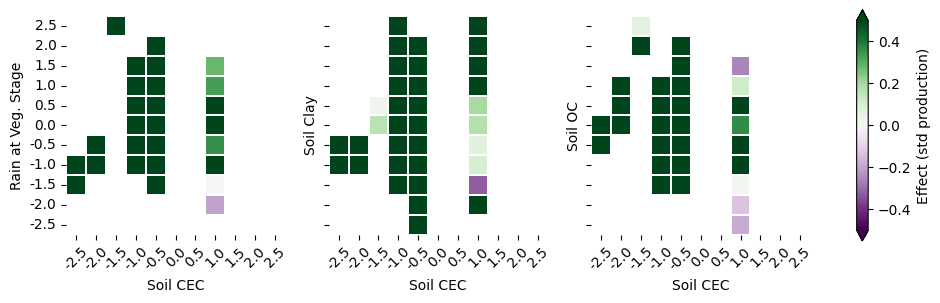

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharex=True, sharey=True)

plot_2d_cate(
    'accessibility_rai', 'soilfert_oc', 'Soil CEC', 'Rain at Veg. Stage', tlearner_est, axes[0],
    domain_width=5., nbins=10, vmin=-.3, vmax=.3
)
plot_2d_cate(
    'accessibility_rai', 'wthseason_srad', 'Soil CEC', 'Soil Clay', tlearner_est, axes[1],
    domain_width=5., nbins=10, vmin=-.3, vmax=.3
)
plot_2d_cate(
    'accessibility_rai', 'soilpp_clay', 'Soil CEC', 'Soil OC', tlearner_est, axes[2],
    domain_width=5., nbins=10, vmin=-.3, vmax=.3
)
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=mpl.cm.get_cmap('PRGn'), norm=mpl.colors.Normalize(-.5, .5)),
    ax=axes, extend='both', label='Effect (std production)', shrink=.6
)

### Identifying potential positive effects

In [144]:
potential_advice_ids = X_df.loc[(individual_effects[('TLearner', 'ci-low')] > 0) & ~T].index
potential_advice_ids

Index(['y0q886YDHg', 'NfyUaHgMdC', 'qfciDGlEMA', '1LW4dvza0v', '1xFMEjWJJx',
       '0ApZrp3h75', 'fqiaqApdbF', 'AutzNmQkZk', 'sfvsUfRoWV', 'G7LqrtsGMD',
       ...
       '2hv8G8YjPk', 'zIBi1X9Vjh', 'yzdMSB6l9k', 'YZUWxXsPD9', 'SK0A0kWT0y',
       'xCeHEt5z1Y', 'DtchFZ4QLp', 'm7YR9SViWt', 'ETlUgcXzqJ', 'W6eS5T0x90'],
      dtype='object', length=296)

In [151]:
X_df.shape

In [145]:
data_subset.loc[potential_advice_ids].crop_maize.mean()

In [146]:
tlearner_est.ate_inference(X[X_df.index.isin(potential_advice_ids), :])

In [149]:
# Convert the effect back to kg/ha
stdprod_mu, stdprod_sd = data.maizeprodkg_ha.mean(), data.maizeprodkg_ha.std()
0.121*stdprod_sd, 1.001*stdprod_sd, 1.881*stdprod_sd

In [152]:
0.296*stdprod_sd, 0.542*stdprod_sd, 1.709*stdprod_sd

In [148]:
fert_df_values.fertP_56leaves.loc[fert_df_values.fertP_56leaves > 0].describe()

count    111.000000
mean      30.626785
std       12.617005
min       10.316764
25%       23.072970
50%       27.467869
75%       35.869420
max       95.649287
Name: fertP_56leaves, dtype: float64

## Spatial visualization of the effect

### Functions and data

In [334]:
points = gpd.read_file('data/geo/points.geojson')
points = points.set_index('fieldID')
crs = 'EPSG:32736'
gdf = gpd.read_file('data/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
gdf = gdf.to_crs(crs)
boundary = gpd.GeoSeries(gdf.union_all().boundary)

In [335]:
points_gdf = gpd.GeoDataFrame(X_df.join(points[['geometry']]))
points_gdf = points_gdf.join(individual_effects['TLearner'])
points_gdf['to_advice'] = 0
points_gdf.loc[X_df.loc[(individual_effects[('TLearner', 'ci-low')] > 0) & ~T].index, 'to_advice'] = 1
points_gdf[outcome_name] = Y
points_gdf[treatment_name] = T

In [336]:
def get_raster_from_points(varname, dx=5000):
    '''
    Generates a raster by averaging the points contained within each cell.
    dx is the raster resolution. 
    '''
    z = points_gdf[varname]
    x = points_gdf.geometry.x
    y = points_gdf.geometry.y 
    
    tmp_df = pd.DataFrame({'x': x, 'y': y, 'z': z}).sort_values(by=['x', 'y'])
    
    ulx = dx*(tmp_df.x.min()//dx)
    uly = dx*(tmp_df.y.max()//dx)
    lrx = dx*(tmp_df.x.max()//dx)
    lry = dx*(tmp_df.y.min()//dx)
    
    xx, yy = np.meshgrid(
        np.linspace(int(ulx), int(llx), int((lrx-ulx+dx)/dx)),
        np.linspace(int(lry), int(uly), int((uly-lly+dx)/dx))
    )
    zz = np.zeros_like(xx)
    zz = np.where(zz==0, np.nan, zz)
    
    ii, jj = np.indices(zz.shape)
    
    for i, j in zip(ii.flatten(), jj.flatten()):
        x_ij = xx[i, j]
        y_ij = yy[i, j]
        z_subset = z[
            ((x>(x_ij-dx/2)) & (x<=(x_ij+dx/2))) &
            ((y>(y_ij-dx/2)) & (y<=(y_ij+dx/2)))
        ]
        if len(z_subset) < 2:
            continue
        zz[i, j] = z_subset.mean()
    zz = zz[::-1,:]
    rds = xr.DataArray(
        data=zz,
        coords={'y': yy[::-1, 0], 'x': xx[0]},
        dims=['y', 'x'],
        name='z'
    )
    rds = rds.rio.write_crs("EPSG:32736")
    return rds

In [337]:
def add_raster_layer(m:folium.Map, rds:xr.Dataset, cmap='RdYlBu', vmin=0, vmax=1):
    '''
    Adds a rioxarray raster to the map
    '''
    rds_wgs84 = rds.rio.reproject("EPSG:4326")
    data_to_plot = rds_wgs84.squeeze() # Remove the band dimension if it exists
    min_val = data_to_plot.min().item()
    max_val = data_to_plot.max().item()
    image_array = ((data_to_plot - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    bounds_latlon = rds_wgs84.rio.bounds()
    folium_bounds = [
        [bounds_latlon[1], bounds_latlon[0]], # min_lat, min_lon
        [bounds_latlon[3], bounds_latlon[2]]  # max_lat, max_lon
    ]
    cmap = plt.get_cmap(cmap) 
    norm = Normalize(vmin=vmin, vmax=vmax)
    colors_rgba = cmap(norm(data_to_plot.values))
    colors_rgba[np.isnan(image_array), 3] = 0

    raster_layer = raster_layers.ImageOverlay(
        image=colors_rgba,
        bounds=folium_bounds,
        opacity=1,
        name='My Raster Data'
    )
    raster_layer.add_to(m)

In [338]:
points_gdf_wg84 = points_gdf.to_crs(4326)

def add_points_to_map(varname:str, cmap='viridis', vmin=0, vmax=1, cbarlabel='Value', 
                      layername='layer', add_colormap=False):
    cmap = plt.get_cmap(cmap) 
    colormap = cm.LinearColormap(
        colors=[cmap(i) for i in np.linspace(0, 1, 10)], # Get colors from cmap
        vmin=vmin,
        vmax=vmax,
        caption=cbarlabel # The label for the colorbar
    )
    
    points_layer = folium.FeatureGroup(name=layername)
    for _, row in points_gdf_wg84.iterrows():
        popup = f"Value: {row[varname]:.3f}"
        if varname == 'effect':
            popup=str(row.to_dict())
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=5,
            color=None, # Set border color to None
            fill=True,
            fill_color=colormap(row[varname]), # Use the colormap to set the fill color
            fill_opacity=1,
            popup=popup
        ).add_to(points_layer)
    points_layer.add_to(m)
    if add_colormap: colormap.add_to(m)
    

### Map

In [339]:
map_center = [points_gdf_wg84.geometry.y.mean(), points_gdf_wg84.geometry.x.mean()]
m = folium.Map(location=map_center, zoom_start=8, tiles="CartoDB positron")
tile = folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Esri Satellite',
    overlay=False,
    control=True,
    show=False
).add_to(m)
# add_points_to_map(
#     'soilfert_oc', cmap='bwr', vmin=-2, vmax=2,
#     cbarlabel='Standardized Variable',
#     layername='SOC', add_colormap=True
# )
# add_points_to_map(
#     'wthstage_rainp0to60', cmap='bwr', vmin=-2, vmax=2,
#     layername='Precipitation'
# )
# add_points_to_map(
#     'wthseason_tmean', cmap='bwr', vmin=-2, vmax=2,
#     layername='Temperature'
# )
# add_points_to_map(
#     'fieldsize_value', cmap='bwr', vmin=-2, vmax=2,
#     layername='Field size'
# )
# add_points_to_map(
#     outcome_name, cmap='magma', vmin=-2, vmax=2,
#     layername='Standardized Production'
# )
add_points_to_map(
    'ci-low', cmap='viridis', vmin=0, vmax=.5,
    cbarlabel='Effect of treatment on production (std, lower CI)',
    layername="Effect", add_colormap=True
)

add_points_to_map(
    'to_advice', cmap='viridis', vmin=0, vmax=.5,
    cbarlabel='Effect of treatment on production (std)',
    layername="To advice", add_colormap=True
)
folium.LayerControl().add_to(m)
m

# Conclusions
